# check tta layers diff

## import

In [83]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import argparse
import random

import numpy as np
import torch
import torch.backends.cudnn as cudnn

import lavis.tasks as tasks
from lavis.common.config import Config
from lavis.common.dist_utils import get_rank, init_distributed_mode
from lavis.common.logger import setup_logger
from lavis.common.optims import (
    LinearWarmupCosineLRScheduler,
    LinearWarmupStepLRScheduler,
)
from lavis.common.utils import now

# imports modules for registration
from lavis.datasets.builders import *
from lavis.models import *
from lavis.processors import *
from lavis.runners.runner_base import RunnerBase
from lavis.tasks import *


def setup_seeds(config):
    seed = config.run_cfg.seed + get_rank()

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    cudnn.benchmark = False
    cudnn.deterministic = True

/home/jiahao/miniconda3/envs/blip2/lib/python3.11/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## model_origin

In [84]:
args = argparse.Namespace(
    is_tta=True,
    cfg_path="lavis/projects/blip2/eval/ret_coco_eval_tent_debug_experiments.yaml",
    options=[]
)

job_id = now()

cfg = Config(args)

init_distributed_mode(cfg.run_cfg)

setup_seeds(cfg)

# set after init_distributed_mode() to only log on master.
setup_logger()

cfg.pretty_print()


2025-07-07 08:59:53,134 [INFO] 
=====  Running Parameters    =====
2025-07-07 08:59:53,135 [INFO] {
    "batch_size_eval": 16,
    "batch_size_train": 16,
    "device": "cuda",
    "dist_url": "env://",
    "distributed": false,
    "evaluate": true,
    "k_test": 128,
    "num_workers": 4,
    "output_dir": "output/BLIP2/Retrieval_COCO_tent_debug_experiments",
    "seed": 42,
    "task": "retrieval",
    "test_splits": [
        "test"
    ],
    "train_splits": [
        "train"
    ],
    "use_dist_eval_sampler": false,
    "valid_splits": [
        "val"
    ],
    "world_size": 1
}
2025-07-07 08:59:53,136 [INFO] 
======  Dataset Attributes  ======
2025-07-07 08:59:53,137 [INFO] 
======== coco_retrieval =======
2025-07-07 08:59:53,139 [INFO] {
    "build_info": {
        "annotations": {
            "test": {
                "md5": "3ff34b0ef2db02d01c37399f6a2a6cd1",
                "storage": "coco/annotations/coco_karpathy_test.json",
                "url": "https://storage.googl

Not using distributed mode


In [85]:
task = tasks.setup_task(cfg)
datasets = task.build_datasets(cfg)
model = task.build_model(cfg)

# runner = RunnerBase(
#     cfg=cfg, job_id=job_id, task=task, model=model, datasets=datasets
# )
# runner.evaluate(skip_reload=True)
# runner.evaluate_tta(skip_reload=True, tta_cfg=cfg.config.tta)


100%|██████████| 84.6M/84.6M [00:14<00:00, 5.82MB/s]
100%|██████████| 1.74M/1.74M [00:01<00:00, 1.67MB/s]
100%|██████████| 1.74M/1.74M [00:01<00:00, 1.62MB/s]
2025-07-07 09:00:12,585 [WARNING] /home/jiahao/task/LAVIS/lavis/datasets/builders/base_dataset_builder.py:169: UserWarning: 
                The specified path /home/jiahao/data/coco/images/ for visual inputs does not exist.
                Please provide a correct path to the visual inputs or
                refer to datasets/download_scripts/README.md for downloading instructions.
                
  warnings.warn(

2025-07-07 09:00:12,586 [INFO] Building datasets...
2025-07-07 09:00:12,590 [WARNING] /home/jiahao/task/LAVIS/lavis/datasets/builders/base_dataset_builder.py:229: UserWarning: storage path /home/jiahao/data/coco/images/ does not exist.
  warnings.warn("storage path {} does not exist.".format(vis_path))

2025-07-07 09:00:13,549 [WARNING] /home/jiahao/miniconda3/envs/blip2/lib/python3.11/site-packages/huggingface_hub/f

Position interpolate from 16x16 to 26x26


2025-07-07 09:00:40,798 [INFO] Missing keys []
2025-07-07 09:00:40,799 [INFO] load checkpoint from /home/jiahao/pretrain/blip2_finetune_coco.pth


In [ ]:
model


## modal_adapt

In [ ]:
model_adapt = task.build_model(cfg)

state_dict = torch.load("debug/tta_model_model_state_dict_after_i2tadapt_debug.pth", map_location="cpu")
model_adapt.load_state_dict(state_dict, strict=True)

In [ ]:
model_adapt_t2i = task.build_model(cfg)

state_dict_t2i = torch.load("debug/tta_model_model_state_dict_after_t2iadapt_debug.pth", map_location="cpu")
model_adapt_t2i.load_state_dict(state_dict_t2i, strict=True)

## show diff layers

In [ ]:
i = 0
for k,v in model.named_parameters():
    print(k, v.shape)
    # print(v)
    print(type(v))
    i+=1

    if i==5:
        break

In [ ]:
j = 0
# for k,v in state_dict.items():
for k,v in model_adapt.named_parameters():
    print(k, v.shape)
    # print(v)
    print(type(v))
    j+=1

    if j==5:
        break

In [ ]:
j = 0
name_list = []
for ((k,v),(k_adapt,v_adapt)) in zip(model.named_parameters(), model_adapt.named_parameters()):

    # print(k, v.shape)
    # print(k_adapt, v_adapt.shape)
    # print(v)
    # print(type(v))
    diff = (v - v_adapt).detach().numpy().sum()
    if diff != 0:
        print()
        print(k, k_adapt)
        print("DIFF of original & adapted : ")
        print(diff)
        name_list.append(k)

    # try:
    #     diff = (v - v_adapt).detach().numpy().sum()
    #     if diff != 0:
    #         print("DIFF of original & adapted")
    #         print(diff)
    # except:
    #     print("except while comparing original & adapted")
    #     print(v - v_adapt)

    j+=1
    # if j==5:
    #     break

In [ ]:
[ name for name in name_list if "LayerNorm" not in name]

In [ ]:
len(name_list)

In [ ]:
j = 0
name_list_t2i = []
for ((k,v),(k_adapt,v_adapt)) in zip(model.named_parameters(), model_adapt_t2i.named_parameters()):

    # print(k, v.shape)
    # print(k_adapt, v_adapt.shape)
    # print(v)
    # print(type(v))
    diff = (v - v_adapt).detach().numpy().sum()
    if diff != 0:
        # print()
        # print(k, k_adapt)
        # print("DIFF of original & adapted : ")
        # print(diff)
        name_list_t2i.append(k)

    # try:
    #     diff = (v - v_adapt).detach().numpy().sum()
    #     if diff != 0:
    #         print("DIFF of original & adapted")
    #         print(diff)
    # except:
    #     print("except while comparing original & adapted")
    #     print(v - v_adapt)

    j+=1
    # if j==5:
    #     break

print([ name for name in name_list_t2i if "LayerNorm" not in name])
print(len(name_list_t2i))
print(name_list_t2i)

## diff of layer_list between t2i & i2t

In [ ]:
diff_elements = list(set(name_list) - set(name_list_t2i))
print(len(diff_elements))

print("\r\n layers in i2t, not in t2i: ")
for e in diff_elements:
    if e not in name_list_t2i:
        print(e)

In [ ]:
diff_elements = list(set(name_list_t2i) - set(name_list))
print(len(diff_elements))

print("\r\n layers in t2i, not in i2t: ")
for e in diff_elements:
    if e not in name_list:
        print(e)



In [ ]:
name_list_layer_norm = []
for ((k,v),(k_adapt,v_adapt)) in zip(model.named_parameters(), model_adapt_t2i.named_parameters()):
    if "LayerNorm" in k:
        name_list_layer_norm.append(k)

print(len(name_list_layer_norm))
print(name_list_layer_norm)

In [ ]:
diff_elements_i2t_pretrain = list(set(name_list_layer_norm) - set(name_list))
print("all layer_norm list - i2t list :", len(diff_elements_i2t_pretrain))

print(diff_elements_i2t_pretrain)



In [ ]:
diff_elements_t2i_pretrain = list(set(name_list_layer_norm) - set(name_list_t2i))
print("all layer_norm list - t2i list :", len(diff_elements_t2i_pretrain))

print(diff_elements_t2i_pretrain)

In [ ]:
torch.cuda.empty_cache()

## conclusion

- state_dict来自于tent，由于仅在recall阶段进行tta，image和text的feature都由Qformer计算，但不进行cross-attention交互，且各自有不同的输出head；
- 当 i2t tta时，Qformer中与image_embed输出相关的output模块不参与adapt，而text_input需要经过init_hidden_states=None的cross-attention模块输出text_embed，故cross-attention参与了adapt；
- 当 t2i tta时，Qformer中与text_embed输出相关的output_query模块和cross-attention模块不参与adapt；


# analysis rerank performance

## load sims_matrix and score_i2t/t2i

In [ ]:
import numpy as np

# Load the npy files
sims_i2t = np.load("debug/sims_matrix_debug.npy").transpose(1,0)
sims_t2i = np.load("debug/sims_matrix_debug.npy")
score_i2t = np.load("debug/score_matrix_i2t_debug.npy")
score_t2i = np.load("debug/score_matrix_t2i_debug.npy")

print("sims_i2t shape:", sims_i2t.shape)
print("sims_t2i shape:", sims_t2i.shape)
print("score_i2t shape:", score_i2t.shape)
print("score_t2i shape:", score_t2i.shape)

In [ ]:
import numpy as np

# Calculate mean, max, min, median for sims_i2t
sims_i2t_mean = np.mean(sims_i2t)
sims_i2t_max = np.max(sims_i2t)
sims_i2t_min = np.min(sims_i2t)
sims_i2t_median = np.median(sims_i2t)

# Calculate mean, max, min, median for score_i2t
score_i2t_mean = np.mean(score_i2t)
score_i2t_max = np.max(score_i2t)
score_i2t_min = np.min(score_i2t)
score_i2t_median = np.median(score_i2t)

print(sims_i2t_mean, sims_i2t_max, sims_i2t_min, sims_i2t_median)
print(score_i2t_mean, score_i2t_max, score_i2t_min, score_i2t_median)

## i2t 计算topk分数

### recall

In [ ]:
k = 128
## 按照sims without rerank排序
topk_idx_sims = np.argsort(-sims_i2t, axis=1)[:, :k]  # 按行取前 k 个索引
topk_sims = np.take_along_axis(sims_i2t, topk_idx_sims, axis=1)

topk_score = np.take_along_axis(score_i2t, topk_idx_sims, axis=1)
# 这里的topk_score是按照topk_sims的topk顺序进行排序的

# score = itm_score + topk_sim
itm_score = topk_score - topk_sims
# 这里的itm_score是按照topk_sims的topk顺序进行排序的

In [ ]:
np.where(score_i2t > -100,1,0).sum() / 5000

In [ ]:
topk_sims[0][:10], itm_score[0][:10], topk_score[0][:10]

In [ ]:
itm_score.shape

In [ ]:
print(np.mean(topk_sims),np.max(topk_sims),np.min(topk_sims),np.median(topk_sims))
print(np.mean(itm_score),np.max(itm_score),np.min(itm_score),np.median(itm_score))
print(np.mean(topk_score),np.max(topk_score),np.min(topk_score),np.median(topk_score))

In [ ]:
topk_idx_sims[0][:10]

### rerank

In [ ]:
## 按照itm_score only rerank排序
topk_idx_itm_score = np.argsort(-(score_i2t -sims_i2t), axis=1)[:, :k]  # 按行取前 k 个索引
topk_itm_score = np.take_along_axis((score_i2t-sims_i2t), topk_idx_itm_score, axis=1)

In [ ]:
topk_idx_itm_score[0][:10]

### recall + rerank

In [ ]:
## 按照score recall + rerank排序
topk_idx_score = np.argsort(-score_i2t, axis=1)[:, :k]  # 按行取前 k 个索引
topk_score = np.take_along_axis(score_i2t, topk_idx_score, axis=1)


In [ ]:
topk_idx_score[0,:10]

### 加载 test label 分别计算分数

In [ ]:
i2t_label = datasets["coco_retrieval"]["test"].img2txt

In [ ]:
import numpy as np

def calculate_recall(topk_idx_sims, i2t_label):
    total_samples = len(i2t_label)
    recall_at_1 = 0
    recall_at_5 = 0
    recall_at_10 = 0

    for i in range(total_samples):
        true_label = i2t_label[i]
        topk_indices = topk_idx_sims[i]
        r1_flag = False
        r5_flag = False
        r10_flag = False

        for label in true_label:
            if label in topk_indices[:1].tolist():
                r1_flag = True
            if label in topk_indices[:5].tolist():
                r5_flag = True
            if label in topk_indices[:10].tolist():
                r10_flag = True

        if r1_flag:
            recall_at_1 += 1
        if r5_flag:
            recall_at_5 += 1
        if r10_flag:
            recall_at_10 += 1

    recall_at_1 /= total_samples
    recall_at_5 /= total_samples
    recall_at_10 /= total_samples

    return recall_at_1, recall_at_5, recall_at_10

In [ ]:
topk_idx_sims[0][:10].tolist()

In [ ]:
i2t_label[0]

In [ ]:
# 调用方法并输出结果
recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_sims, i2t_label)
print("recall")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_itm_score, i2t_label)
print("rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_score, i2t_label)
print("recall+rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

## t2i 计算topk分数

### recall

In [ ]:
k = 128
## 按照sims without rerank排序
topk_idx_sims = np.argsort(-sims_t2i, axis=1)[:, :k]  # 按行取前 k 个索引
topk_sims = np.take_along_axis(sims_t2i, topk_idx_sims, axis=1)

topk_score = np.take_along_axis(score_t2i, topk_idx_sims, axis=1)
# 这里的topk_score是按照topk_sims的topk顺序进行排序的

# score = itm_score + topk_sim
itm_score = topk_score - topk_sims
# 这里的itm_score是按照topk_sims的topk顺序进行排序的

In [ ]:
np.where(score_t2i > -100,1,0).sum() / 25010

In [ ]:
topk_sims[0][:10], itm_score[0][:10], topk_score[0][:10]

In [ ]:
itm_score.shape

In [ ]:
print(np.mean(topk_sims),np.max(topk_sims),np.min(topk_sims),np.median(topk_sims))
print(np.mean(itm_score),np.max(itm_score),np.min(itm_score),np.median(itm_score))
print(np.mean(topk_score),np.max(topk_score),np.min(topk_score),np.median(topk_score))

In [ ]:
topk_idx_sims[0][:10]

### rerank

In [ ]:
## 按照itm_score only rerank排序
topk_idx_itm_score = np.argsort(-(score_t2i -sims_t2i), axis=1)[:, :k]  # 按行取前 k 个索引
topk_itm_score = np.take_along_axis((score_t2i-sims_t2i), topk_idx_itm_score, axis=1)

In [ ]:
topk_idx_itm_score[0][:10]

### recall + rerank

In [ ]:
## 按照score recall + rerank排序
topk_idx_score = np.argsort(-score_t2i, axis=1)[:, :k]  # 按行取前 k 个索引
topk_score = np.take_along_axis(score_t2i, topk_idx_score, axis=1)


In [ ]:
topk_idx_score[0,:10]

### 加载 test label 分别计算分数

In [ ]:
t2i_label = datasets["coco_retrieval"]["test"].txt2img

In [ ]:
import numpy as np

def calculate_recall(topk_idx_sims, t2i_label):
    total_samples = len(t2i_label)
    recall_at_1 = 0
    recall_at_5 = 0
    recall_at_10 = 0

    for i in range(total_samples):
        true_label = t2i_label[i]
        topk_indices = topk_idx_sims[i]
        if true_label in topk_indices[:1].tolist():
            recall_at_1 += 1
        if true_label in topk_indices[:5].tolist():
            recall_at_5 += 1
        if true_label in topk_indices[:10].tolist():
            recall_at_10 += 1

    recall_at_1 /= total_samples
    recall_at_5 /= total_samples
    recall_at_10 /= total_samples

    return recall_at_1, recall_at_5, recall_at_10

In [ ]:
topk_idx_sims[0][:10].tolist()

In [ ]:
t2i_label[0]

In [ ]:
# 调用方法并输出结果
recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_sims, t2i_label)
print("recall")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_itm_score, t2i_label)
print("rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_score, t2i_label)
print("recall+rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

## analysis

- 在cos_sim不除以temperature的情况下，cos_sim的取值范围为-1,1；而itm_score的取值范围为0,15以上；
- 二者量纲并不相同，而在blip和blip2中，作者的代码将两者相加，达成了使用cos_sim微调itm_score的效果；
- 根据metric在i2t中仅使用itm_score，recall@1会上升，但recall@5和10会下降；
- 根据metric在t2i中仅使用itm_score，recall@1,recall@5,recall@10均会下降；

# TODO
## metric of ss=cos_sim_top1

# Score数值 (Temperature or Label Smoothing Strategy)

## ex 1 cos_sim

In [ ]:
import torch
import numpy as np
import random

random_list = [random.uniform(0, 0.01) for _ in range(123)]
print(random_list)
topk_list = [0.51, 0.5, 0.45, 0.42, 0.41]
topk_list.extend(random_list)
print(topk_list)
topk_tensor = torch.Tensor(topk_list)
print(topk_tensor)

In [ ]:
import torch.nn.functional as F
# print(F.softmax(topk_tensor, dim=0))
# print(F.log_softmax(topk_tensor, dim=0))
# print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)))
print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)).sum())

print(F.softmax(topk_tensor, dim=0))

In [ ]:
print(-(F.sigmoid(topk_tensor) * torch.log(F.sigmoid(topk_tensor))).sum())

print(F.sigmoid(topk_tensor) )

## ex 2 cos_sim

In [ ]:
# random_list = [random.uniform(0, 0.01) for _ in range(127)]
random_list = [0.1/127 for _ in range(127)]
print(random_list)
topk_list = [0.9]
topk_list.extend(random_list)
print(topk_list)
topk_tensor = torch.Tensor(topk_list)
print(topk_tensor)

In [ ]:
import math

In [ ]:
print(F.softmax(topk_tensor, dim=0))
# print([ math.log(x) for x in F.softmax(topk_tensor, dim=0).numpy().tolist() ])
# print(F.log_softmax(topk_tensor, dim=0))
# print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)))
print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)).sum())

In [ ]:
print(-(F.sigmoid(topk_tensor) * torch.log(F.sigmoid(topk_tensor))).sum())

print(F.sigmoid(topk_tensor) )

In [ ]:
print(F.sigmoid(torch.Tensor([0.9])) )

print(F.sigmoid(torch.Tensor([0.1/127])) )
print(F.sigmoid(torch.Tensor([-0.9])) )
print(F.sigmoid(torch.Tensor([-9])) )

## ex 3 score

In [ ]:
# random_list = [random.uniform(0, 0.01) for _ in range(127)]
random_list = [-5 for _ in range(127)]
print(random_list)
topk_list = [4]
topk_list.extend(random_list)
print(topk_list)
topk_tensor = torch.Tensor(topk_list)
print(topk_tensor)

In [ ]:
print(F.softmax(topk_tensor, dim=0))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
# print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)))
print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)).sum())

In [ ]:
print(-(F.sigmoid(topk_tensor) * torch.log(F.sigmoid(topk_tensor))).sum())

print(F.sigmoid(topk_tensor) )

## ex 4 score

In [ ]:
score = torch.Tensor([ 2.5251,  1.7987,  2.4984,  2.5456,  0.3018,  0.6873,  1.4105,  0.7351,
         0.3194,  1.4600,  0.2504, -2.3080, -0.3669, -1.0338, -0.8816, -1.0167,
        -2.3506, -3.9693, -0.2150, -0.0291, -1.4228, -2.3420, -0.1471, -3.8148,
        -2.0076, -1.8196, -2.3271, -0.7736, -2.6617, -0.2045, -3.0147, -0.3503,
        -1.4831, -2.4310, -0.6229, -1.0497, -4.0194, -1.7258, -3.2078, -1.6475,
        -0.6561, -2.3149, -0.2777, -4.9612, -4.4866, -3.2148, -3.3607, -1.1115,
        -1.6387, -2.0795, -3.3493, -3.4117, -2.4388, -0.3735, -4.3452, -4.9870,
        -0.5091, -3.6897, -2.1280, -1.6361, -3.8723, -3.5618, -4.1496, -5.4335,
        -4.9748, -3.9281, -1.5872, -2.4761, -4.1328, -3.3151, -0.7322, -3.8610,
        -3.3226, -3.7666, -0.8437, -0.8367, -2.7714, -2.7362, -3.1571, -1.3180,
        -3.0055, -3.7977, -3.6444, -3.2574, -2.1181, -0.7243, -2.4106, -3.3575,
        -0.6314, -4.4725, -4.1300, -5.6244, -4.2784, -3.8402, -3.3613, -2.2780,
        -3.9022, -5.2376, -3.6194, -5.0524, -3.3743, -1.7079, -4.7432, -3.7393,
        -4.8307, -2.5210, -1.4971, -2.3383, -0.8525, -3.6789, -2.2030, -2.6994,
        -5.0277, -5.2465, -1.2598, -2.4906, -1.0846, -2.7455, -4.4144, -1.1020,
        -3.3042, -1.0451, -3.5574, -0.6343, -0.8737, -3.4680, -3.5093, -2.6475])

In [ ]:
print(F.softmax(score, dim=0))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
# print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)))
print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)).sum())

In [ ]:
print(F.sigmoid(score))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
# print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)))
print(-(F.sigmoid(score) * torch.log(F.sigmoid(score))).sum())

## ex 5 score

In [ ]:
score = torch.Tensor([ 0.1861, -0.1353,  0.0433,  0.2448,  0.2569,  0.1487, -0.0225,  0.0656,
        -0.1290, -0.1263, -0.1100,  0.0749,  0.1404,  0.0999,  0.0774,  0.7098,
         0.1034,  0.0222,  0.0464,  0.2748,  0.1946,  0.0283, -0.3403,  0.1891,
        -1.2059, -1.3221,  0.2691, -0.1907,  0.0470,  0.1387,  0.3835, -0.0047,
        -0.0721,  0.0430,  0.0228,  0.0412,  0.0233,  0.1505, -0.3700, -0.8372,
         0.1514,  0.0333, -0.0867, -0.7579, -0.2178,  0.0384, -0.3476, -0.5086,
         0.1748, -0.0286, -0.1647, -0.1223, -0.1980,  0.0598, -0.0923, -0.4152,
        -0.7515, -0.2440,  0.1311, -1.4587, -0.1334,  0.0222, -0.3817, -1.1041,
        -0.0721, -0.1133, -0.1733, -0.0421, -0.1024, -0.1077,  0.1378,  0.0955,
        -0.1986, -0.7618,  0.0479, -0.4493, -0.5466, -0.0626, -0.1593, -0.2145,
         0.1208, -1.6073, -0.0514, -1.1260, -0.0346,  0.0127, -0.1411, -0.1093,
        -0.1426, -0.0500, -0.3367, -0.2101, -0.4942, -0.1560, -0.3084, -0.2088,
        -0.3985, -1.3578, -0.2336, -0.1146, -0.0370, -0.0523, -0.1758, -0.0623,
         0.1343, -0.3647, -0.7058, -1.0140, -1.4076, -0.1413, -0.2043, -0.7042,
        -1.4981, -0.3609,  0.1634,  0.0144, -0.2519, -0.2833, -0.2898, -0.4575,
        -0.2307, -0.0288, -0.4821, -0.1848, -0.3248, -0.2738, -0.3510, -0.3737])

In [ ]:
print(F.softmax(score, dim=0))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
print(score.shape)
print((-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0))).shape)
print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)).mean())
print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)).sum())

In [ ]:
print(F.sigmoid(score))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
print((-(F.sigmoid(score) * torch.log(F.sigmoid(score)))).shape)
print(-(F.sigmoid(score) * torch.log(F.sigmoid(score))).mean())
print(-(F.sigmoid(score) * torch.log(F.sigmoid(score))).sum())

## ex 5 cos_sim

In [ ]:
cos_sim = torch.Tensor([0.5292, 0.5214, 0.5199, 0.5109, 0.5083, 0.5016, 0.5011, 0.4996, 0.4989,
        0.4985, 0.4950, 0.4905, 0.4878, 0.4865, 0.4861, 0.4859, 0.4857, 0.4849,
        0.4849, 0.4843, 0.4841, 0.4833, 0.4830, 0.4827, 0.4822, 0.4820, 0.4816,
        0.4800, 0.4799, 0.4797, 0.4790, 0.4782, 0.4780, 0.4779, 0.4773, 0.4763,
        0.4756, 0.4756, 0.4746, 0.4736, 0.4735, 0.4735, 0.4728, 0.4719, 0.4694,
        0.4673, 0.4672, 0.4661, 0.4653, 0.4631, 0.4625, 0.4608, 0.4608, 0.4608,
        0.4600, 0.4592, 0.4590, 0.4589, 0.4581, 0.4577, 0.4573, 0.4570, 0.4567,
        0.4566, 0.4553, 0.4552, 0.4550, 0.4548, 0.4541, 0.4541, 0.4526, 0.4524,
        0.4518, 0.4512, 0.4510, 0.4500, 0.4499, 0.4497, 0.4496, 0.4493, 0.4489,
        0.4485, 0.4480, 0.4479, 0.4479, 0.4477, 0.4474, 0.4473, 0.4473, 0.4472,
        0.4461, 0.4459, 0.4442, 0.4442, 0.4441, 0.4439, 0.4437, 0.4430, 0.4421,
        0.4420, 0.4415, 0.4415, 0.4414, 0.4413, 0.4412, 0.4409, 0.4405, 0.4404,
        0.4402, 0.4402, 0.4399, 0.4389, 0.4381, 0.4379, 0.4375, 0.4374, 0.4365,
        0.4362, 0.4361, 0.4354, 0.4353, 0.4348, 0.4339, 0.4337, 0.4330, 0.4323,
        0.4323, 0.4321])

In [ ]:
print(F.softmax(cos_sim, dim=0))
print(-(F.softmax(cos_sim, dim=0) * F.log_softmax(cos_sim, dim=0)).sum())

In [ ]:
print(F.sigmoid(cos_sim))
print(-(F.sigmoid(cos_sim) * torch.log(F.sigmoid(cos_sim))).sum())

# sigmoid_entropy & sofxmax_entropy

In [ ]:
import torch
from torch.nn import functional as F

logits = torch.Tensor([[0.2, 0.8]])
print(F.softmax(logits))
print(F.sigmoid(logits[0,0]), F.sigmoid(logits[0,1]))
# print(logits.shape)
y = torch.Tensor([1]).long()
# print(y.shape)
print(F.cross_entropy(logits, y))
print(F.binary_cross_entropy_with_logits(torch.Tensor([0.8]), y.float()))
print()
print(F.binary_cross_entropy(torch.Tensor([0.6900]), y.float()))
print(F.binary_cross_entropy(torch.Tensor([0.6457]), y.float()))
print()
print(F.nll_loss(torch.log(F.softmax(logits)), y))
print(F.nll_loss(F.log_softmax(logits), y))
print()
print( -( y.float() * torch.log(torch.Tensor([0.6457])) + (1- y.float()) * torch.log(torch.Tensor([3543])) ) )

# Visulize TTA log

In [ ]:
import json
import numpy as np
import torch
import torch.nn.functional as F

with open("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch0_coeffi_list.json", "rt") as file:
    print(type(file))
    score_list = json.load(file)
    coeffi_list = json.loads(coeffi_list)

print(type(coeffi_list))
print(len(coeffi_list))

In [ ]:
list(coeffi_list[0].keys())


In [ ]:
neg_entropy_list = []
r1_entropy_list = []
r5_entropy_list = []
r10_entropy_list = []

neg_coeffi_list = []
r1_coeffi_list = []
r5_coeffi_list = []
r10_coeffi_list = []

neg_loss_list = []
r1_loss_list = []
r5_loss_list = []
r10_loss_list = []
for coeffi_dict in coeffi_list:
    if coeffi_dict['recall_type'] == "negative sample":
        neg_entropy_list.append(coeffi_dict["entropy"])
        neg_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        neg_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
    elif coeffi_dict['recall_type'] == "recall@1":
        r1_entropy_list.append(coeffi_dict["entropy"])
        r1_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        r1_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
    elif coeffi_dict['recall_type'] == "recall@5":
        r5_entropy_list.append(coeffi_dict["entropy"])
        r5_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        r5_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
    elif coeffi_dict['recall_type'] == "recall@10":
        r10_entropy_list.append(coeffi_dict["entropy"])
        r10_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        r10_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])


In [ ]:
print("length statistics: neg r1 r5 r10")
print(len(neg_entropy_list), len(r1_entropy_list), len(r5_entropy_list), len(r10_entropy_list))

print()
print("entropy statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_list), np.max(neg_entropy_list), np.min(neg_entropy_list), np.median(neg_entropy_list))
print("r1: ", np.mean(r1_entropy_list), np.max(r1_entropy_list), np.min(r1_entropy_list), np.median(r1_entropy_list))
print("r5: ", np.mean(r5_entropy_list), np.max(r5_entropy_list), np.min(r5_entropy_list), np.median(r5_entropy_list))
print("r10: ", np.mean(r10_entropy_list), np.max(r10_entropy_list), np.min(r10_entropy_list), np.median(r10_entropy_list))

print()
print("coeffi statistics: mean max min median")
print("neg: ", np.mean(neg_coeffi_list), np.max(neg_coeffi_list), np.min(neg_coeffi_list), np.median(neg_coeffi_list))
print("r1: ",np.mean(r1_coeffi_list), np.max(r1_coeffi_list), np.min(r1_coeffi_list), np.median(r1_coeffi_list))
print("r5: ", np.mean(r5_coeffi_list), np.max(r5_coeffi_list), np.min(r5_coeffi_list), np.median(r5_coeffi_list))
print("r10: ", np.mean(r10_coeffi_list), np.max(r10_coeffi_list), np.min(r10_coeffi_list), np.median(r10_coeffi_list))

print()
print("loss statistics: mean max min median")
print("neg: ", np.mean(neg_loss_list), np.max(neg_loss_list), np.min(neg_loss_list), np.median(neg_loss_list))
print("r1: ",np.mean(r1_loss_list), np.max(r1_loss_list), np.min(r1_loss_list), np.median(r1_loss_list))
print("r5: ", np.mean(r5_loss_list), np.max(r5_loss_list), np.min(r5_loss_list), np.median(r5_loss_list))
print("r10: ", np.mean(r10_loss_list), np.max(r10_loss_list), np.min(r10_loss_list), np.median(r10_loss_list))

## def coeffi_list_show(json_path):

In [ ]:
def coeffi_list_show(json_path):
    with open(json_path, "rt") as file:
        coeffi_list = json.load(file)
        coeffi_list = json.loads(coeffi_list)

    neg_entropy_list = []
    r1_entropy_list = []
    r5_entropy_list = []
    r10_entropy_list = []

    neg_coeffi_list = []
    r1_coeffi_list = []
    r5_coeffi_list = []
    r10_coeffi_list = []

    neg_loss_list = []
    r1_loss_list = []
    r5_loss_list = []
    r10_loss_list = []
    for coeffi_dict in coeffi_list:
        if coeffi_dict['recall_type'] == "negative sample":
            neg_entropy_list.append(coeffi_dict["entropy"])
            neg_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            neg_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
        elif coeffi_dict['recall_type'] == "recall@1":
            r1_entropy_list.append(coeffi_dict["entropy"])
            r1_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            r1_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
        elif coeffi_dict['recall_type'] == "recall@5":
            r5_entropy_list.append(coeffi_dict["entropy"])
            r5_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            r5_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
        elif coeffi_dict['recall_type'] == "recall@10":
            r10_entropy_list.append(coeffi_dict["entropy"])
            r10_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            r10_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])

    print("length statistics: neg r1 r5 r10")
    print(len(neg_entropy_list), len(r1_entropy_list), len(r5_entropy_list), len(r10_entropy_list))

    print()
    print("entropy statistics: mean max min median")
    print("neg: ", np.mean(neg_entropy_list), np.max(neg_entropy_list), np.min(neg_entropy_list), np.median(neg_entropy_list))
    print("r1: ", np.mean(r1_entropy_list), np.max(r1_entropy_list), np.min(r1_entropy_list), np.median(r1_entropy_list))
    print("r5: ", np.mean(r5_entropy_list), np.max(r5_entropy_list), np.min(r5_entropy_list), np.median(r5_entropy_list))
    print("r10: ", np.mean(r10_entropy_list), np.max(r10_entropy_list), np.min(r10_entropy_list), np.median(r10_entropy_list))

    print()
    print("coeffi statistics: mean max min median")
    print("neg: ", np.mean(neg_coeffi_list), np.max(neg_coeffi_list), np.min(neg_coeffi_list), np.median(neg_coeffi_list))
    print("r1: ",np.mean(r1_coeffi_list), np.max(r1_coeffi_list), np.min(r1_coeffi_list), np.median(r1_coeffi_list))
    print("r5: ", np.mean(r5_coeffi_list), np.max(r5_coeffi_list), np.min(r5_coeffi_list), np.median(r5_coeffi_list))
    print("r10: ", np.mean(r10_coeffi_list), np.max(r10_coeffi_list), np.min(r10_coeffi_list), np.median(r10_coeffi_list))

    print()
    print("loss statistics: mean max min median")
    print("neg: ", np.mean(neg_loss_list), np.max(neg_loss_list), np.min(neg_loss_list), np.median(neg_loss_list))
    print("r1: ",np.mean(r1_loss_list), np.max(r1_loss_list), np.min(r1_loss_list), np.median(r1_loss_list))
    print("r5: ", np.mean(r5_loss_list), np.max(r5_loss_list), np.min(r5_loss_list), np.median(r5_loss_list))
    print("r10: ", np.mean(r10_loss_list), np.max(r10_loss_list), np.min(r10_loss_list), np.median(r10_loss_list))

## exp1.1.2

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch0_coeffi_list.json")

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch1_coeffi_list.json")

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch2_coeffi_list.json")

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch6_coeffi_list.json")

## exp1.1.1

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.1/i2t/20250614073/epoch0_coeffi_list.json")

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.1/i2t/20250614073/epoch3_coeffi_list.json")

## exp1.1.3

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.3/i2t/20250616050/epoch6_coeffi_list.json")

## exp 7.1

In [ ]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp7.1/i2t/20250616193/epoch8_logging_list_tta.json")

## exp 9.0.1 

### eval entropy折线图 rank0

In [ ]:
import json
import numpy as np
import torch
import torch.nn.functional as F


coeffi_lists = []
for epoch in range(9):
    with open(f"/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.0.1/i2t/20250624080/result/rank0_eval_epoch{epoch}_logging_list.json", "rt") as file:
        # print(type(file))
        coeffi_list_src = json.load(file)
        coeffi_list = json.loads(coeffi_list_src)

    print(type(coeffi_list))
    print(len(coeffi_list))
    coeffi_lists.extend(coeffi_list)

print(len(coeffi_lists))

<class 'list'>
1667
<class 'list'>
1667
<class 'list'>
1667
<class 'list'>
1667
<class 'list'>
1667
<class 'list'>
1667
<class 'list'>
1667
<class 'list'>
1667
<class 'list'>
1667
15003


In [142]:
coeffi_lists[0].keys()

dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])

In [ ]:
entropy_list = []
mv_avg_entropy_list = []
i = 0
mv_avg_entropy = 0
mv_avg_num = 1000

for log_dict in coeffi_lists:
    i += 1
    entropy = log_dict["entropy"]
    mv_avg_entropy += entropy / mv_avg_num
    if i == mv_avg_num:
        mv_avg_entropy_list.append(mv_avg_entropy)
        mv_avg_entropy = 0
        i = 0


    entropy_list.append(entropy)



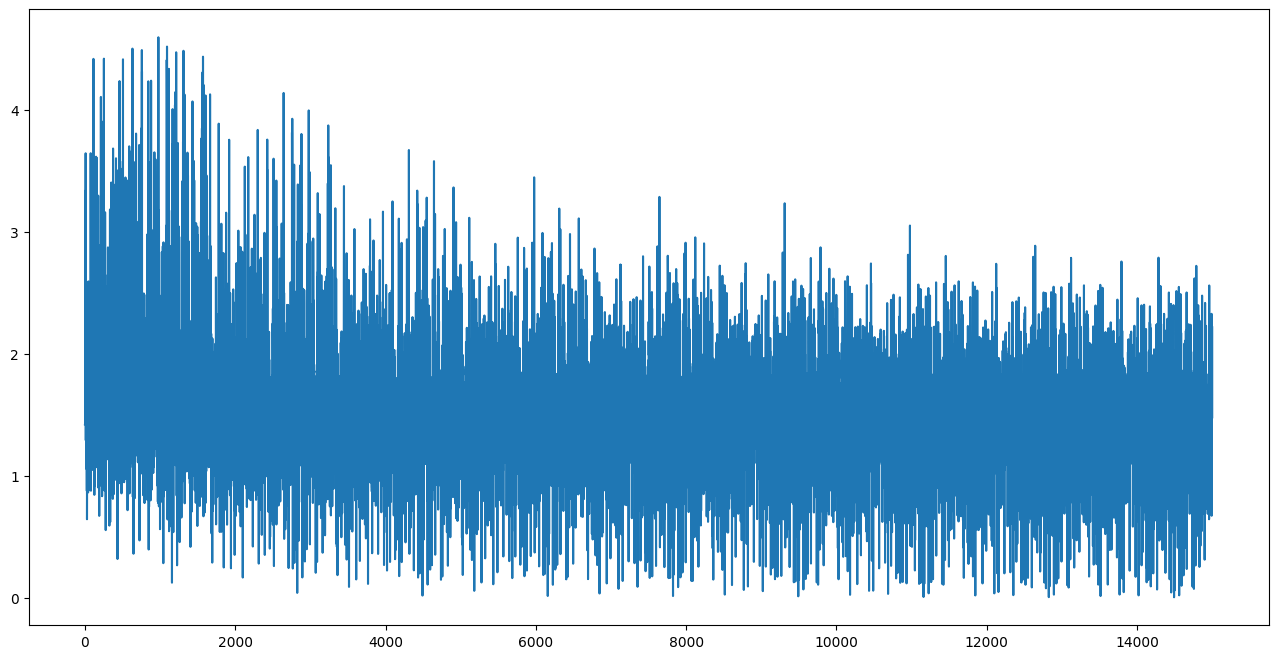

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.plot(range(15003), entropy_list)
plt.show()

In [140]:
mv_avg_entropy_list

[1.805620259940622,
 1.7525231679975997,
 1.5842459373995668,
 1.5357319232150923,
 1.4957192135117952,
 1.4989379533305756,
 1.491645820698701,
 1.4618719662111255,
 1.4782266650591038,
 1.453129681962542,
 1.4456423574723318,
 1.4368809186588047,
 1.414844062257092,
 1.4416285993214697,
 1.4113908650844829]

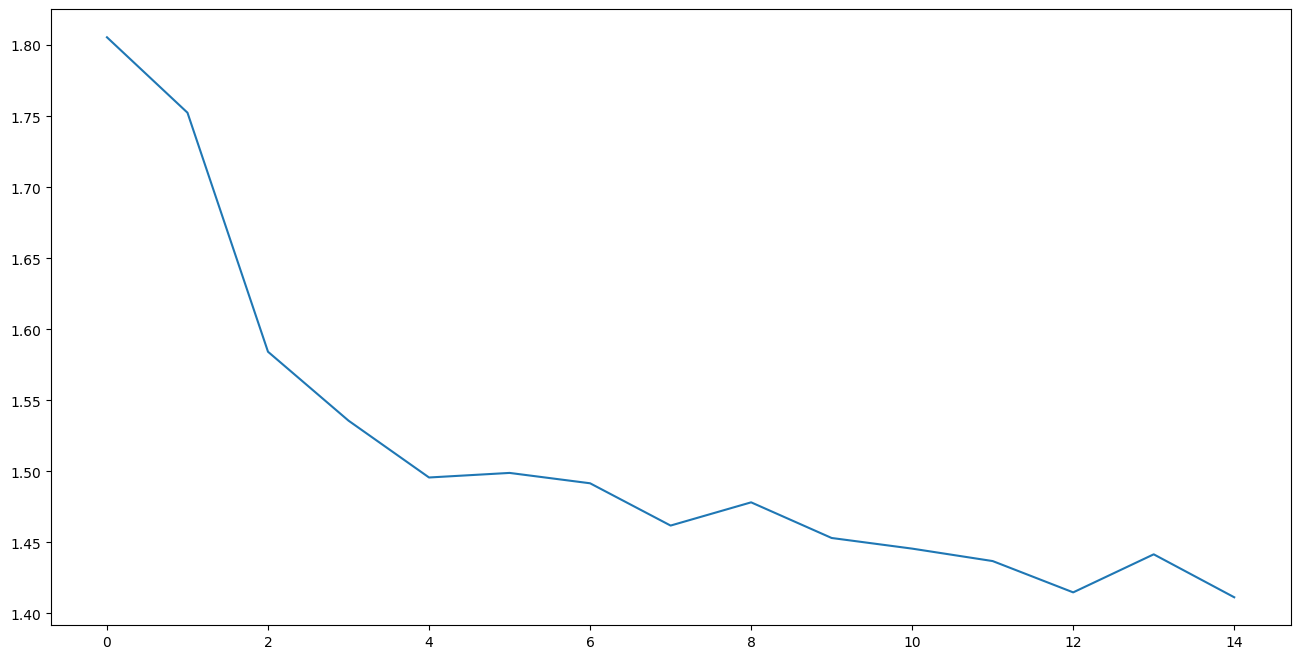

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.plot(mv_avg_entropy_list)
plt.show()

## exp9.2.3

### eval iters折线图 rank0

In [ ]:
import json
import numpy as np
import torch
import torch.nn.functional as F


eval_coeffi_lists = []
for epoch in range(9):
    with open(f"/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.2.3/i2t/20250703210/result/rank0/eval_epoch{epoch}_logging_list.json", "rt") as file:
        # print(type(file))
        coeffi_list_src = json.load(file)
        coeffi_list = json.loads(coeffi_list_src)

    # print(type(coeffi_list))
    print(len(coeffi_list))
    eval_coeffi_lists.extend(coeffi_list)

print(len(eval_coeffi_lists))
print(eval_coeffi_lists[0].keys())
print(eval_coeffi_lists[0]['recall_type'])
print(eval_coeffi_lists[0]['entropy'])
print(len(eval_coeffi_lists[0]['score']))

1667
1667
1667
1667
1667
1667
1667
1667
1667
15003
dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
recall@1
2.1409716606140137
128


#### entropy
eval的entropy由top128 score计算得到，其实没有太大参考意义，；
只要逐步下降即可，类似eval_loss可视化仅供参考即可；

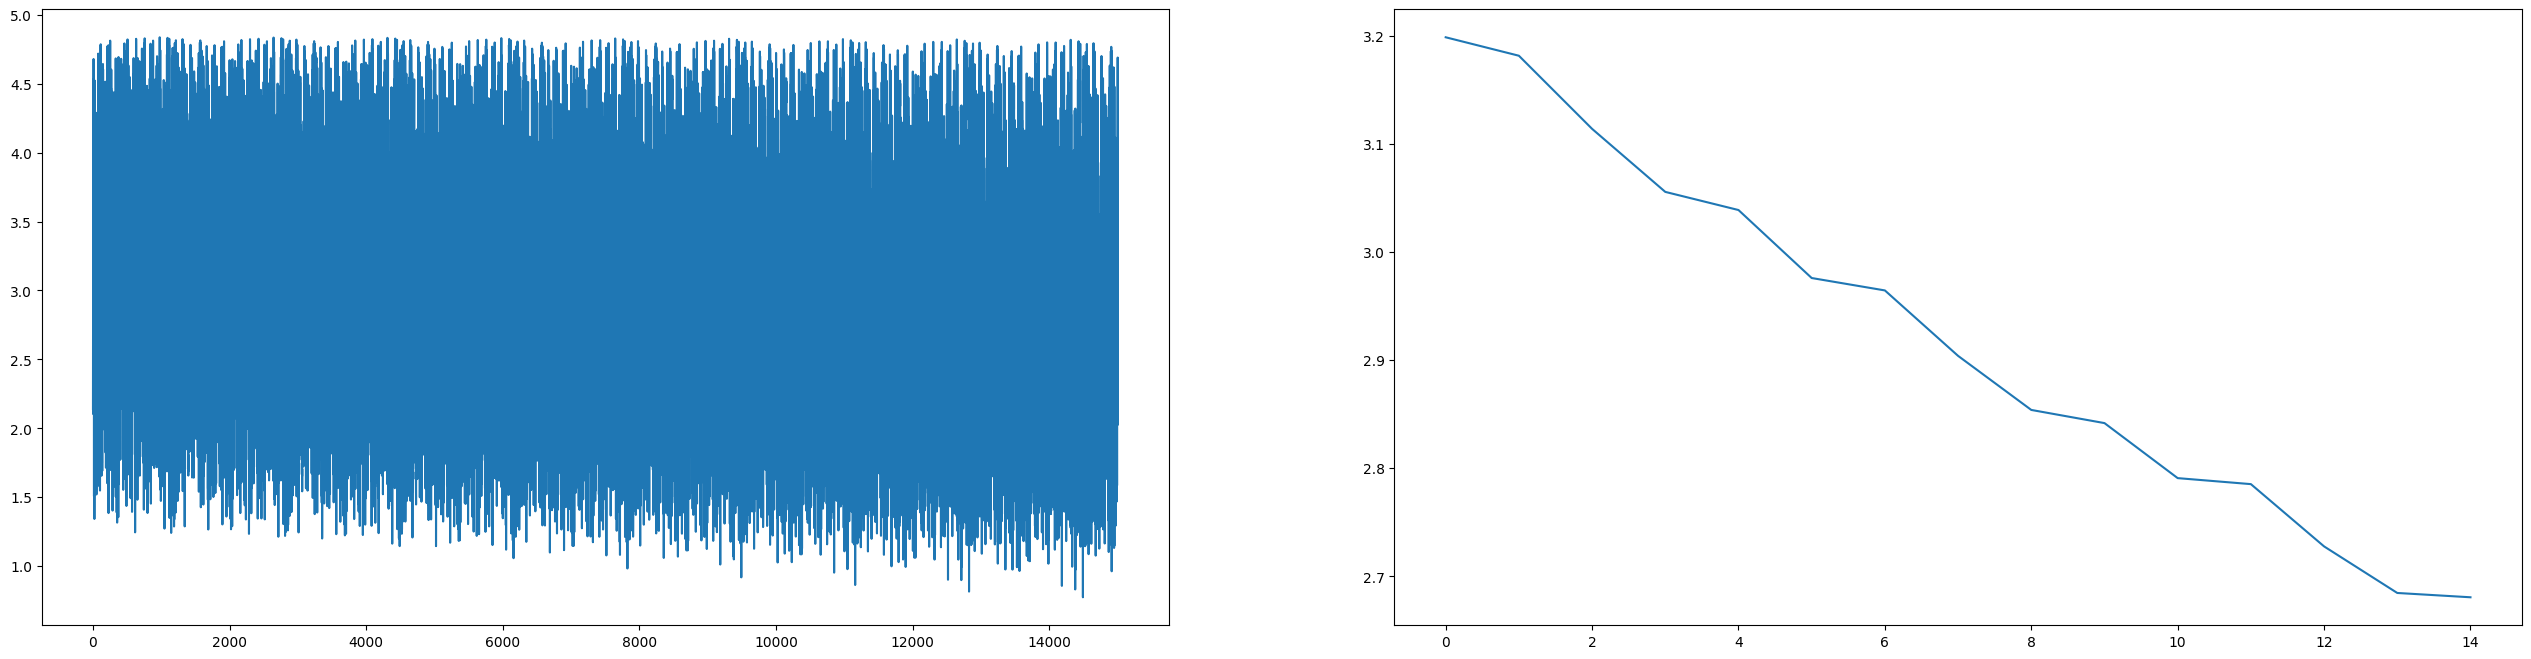

In [55]:
entropy_list = []
mv_avg_entropy_list = []
i = 0
mv_avg_entropy = 0
mv_avg_num = 1000

for log_dict in eval_coeffi_lists:
    i += 1
    # print(log_dict["entropy"])
    entropy = np.mean(log_dict["entropy"])
    # print(entropy)
    mv_avg_entropy += entropy / mv_avg_num
    if i == mv_avg_num:
        mv_avg_entropy_list.append(mv_avg_entropy)
        mv_avg_entropy = 0
        i = 0

    entropy_list.append(entropy)
    # break

import matplotlib.pyplot as plt

plt.figure(figsize=(32,8))
plt.subplot(1,2,1)
plt.plot( entropy_list)
plt.subplot(1,2,2)
plt.plot( mv_avg_entropy_list)
plt.show()

#### score(pos/neg)

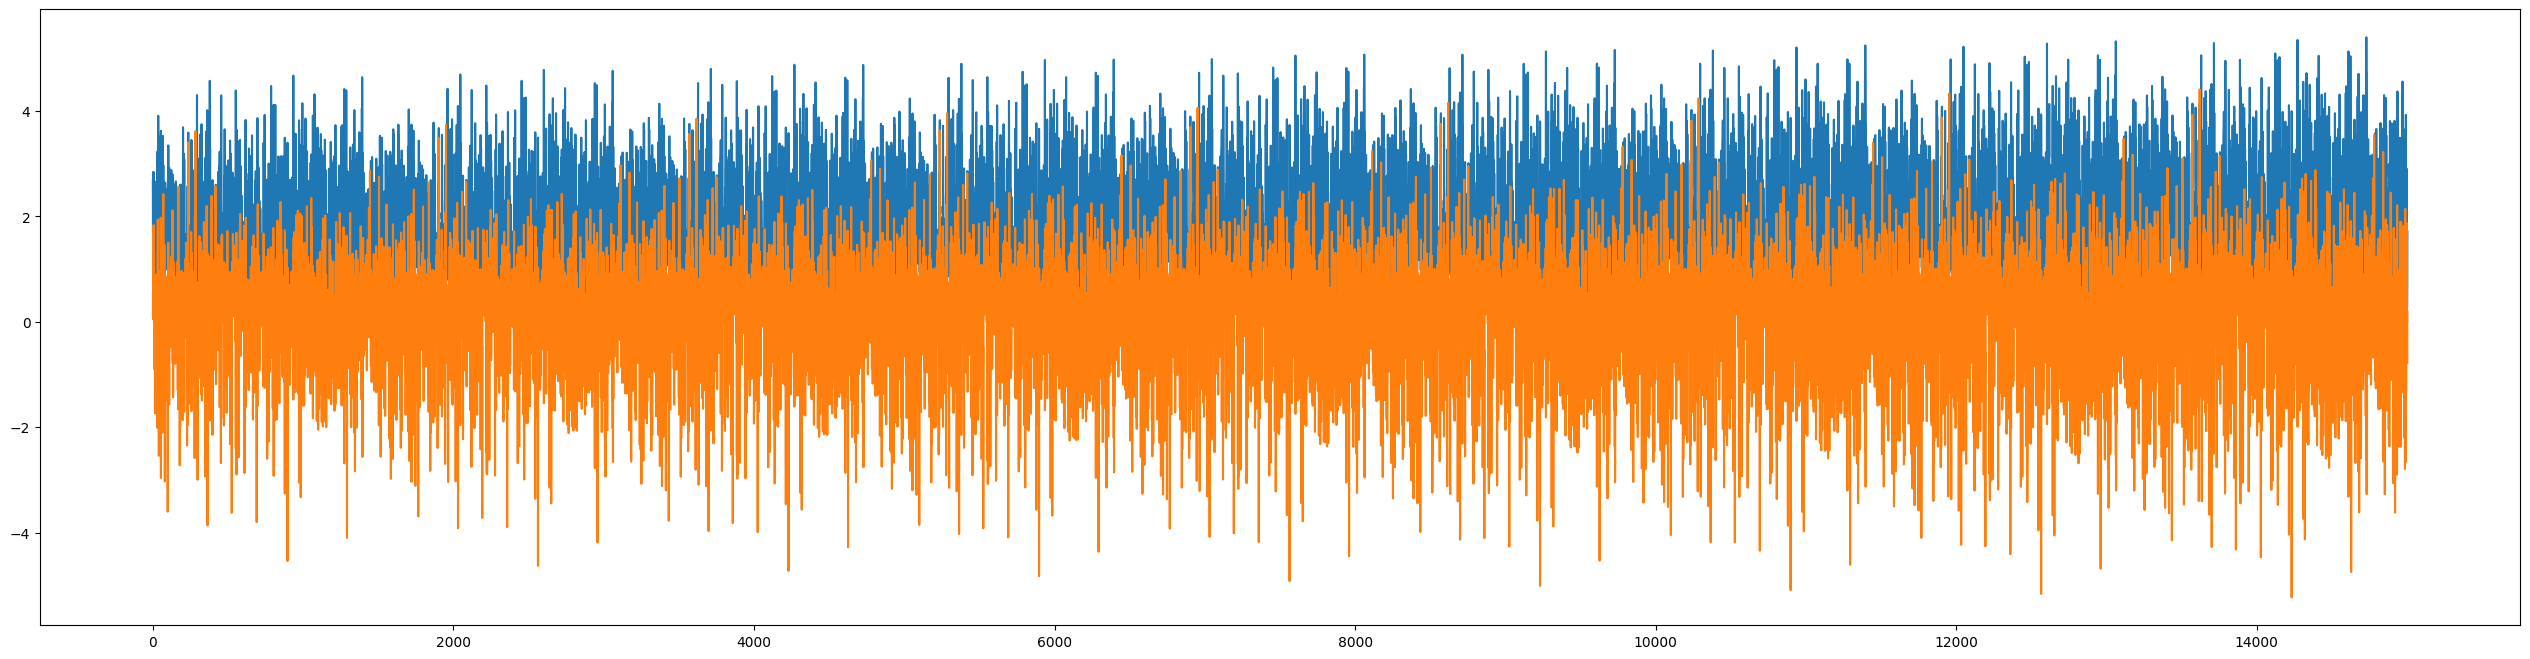

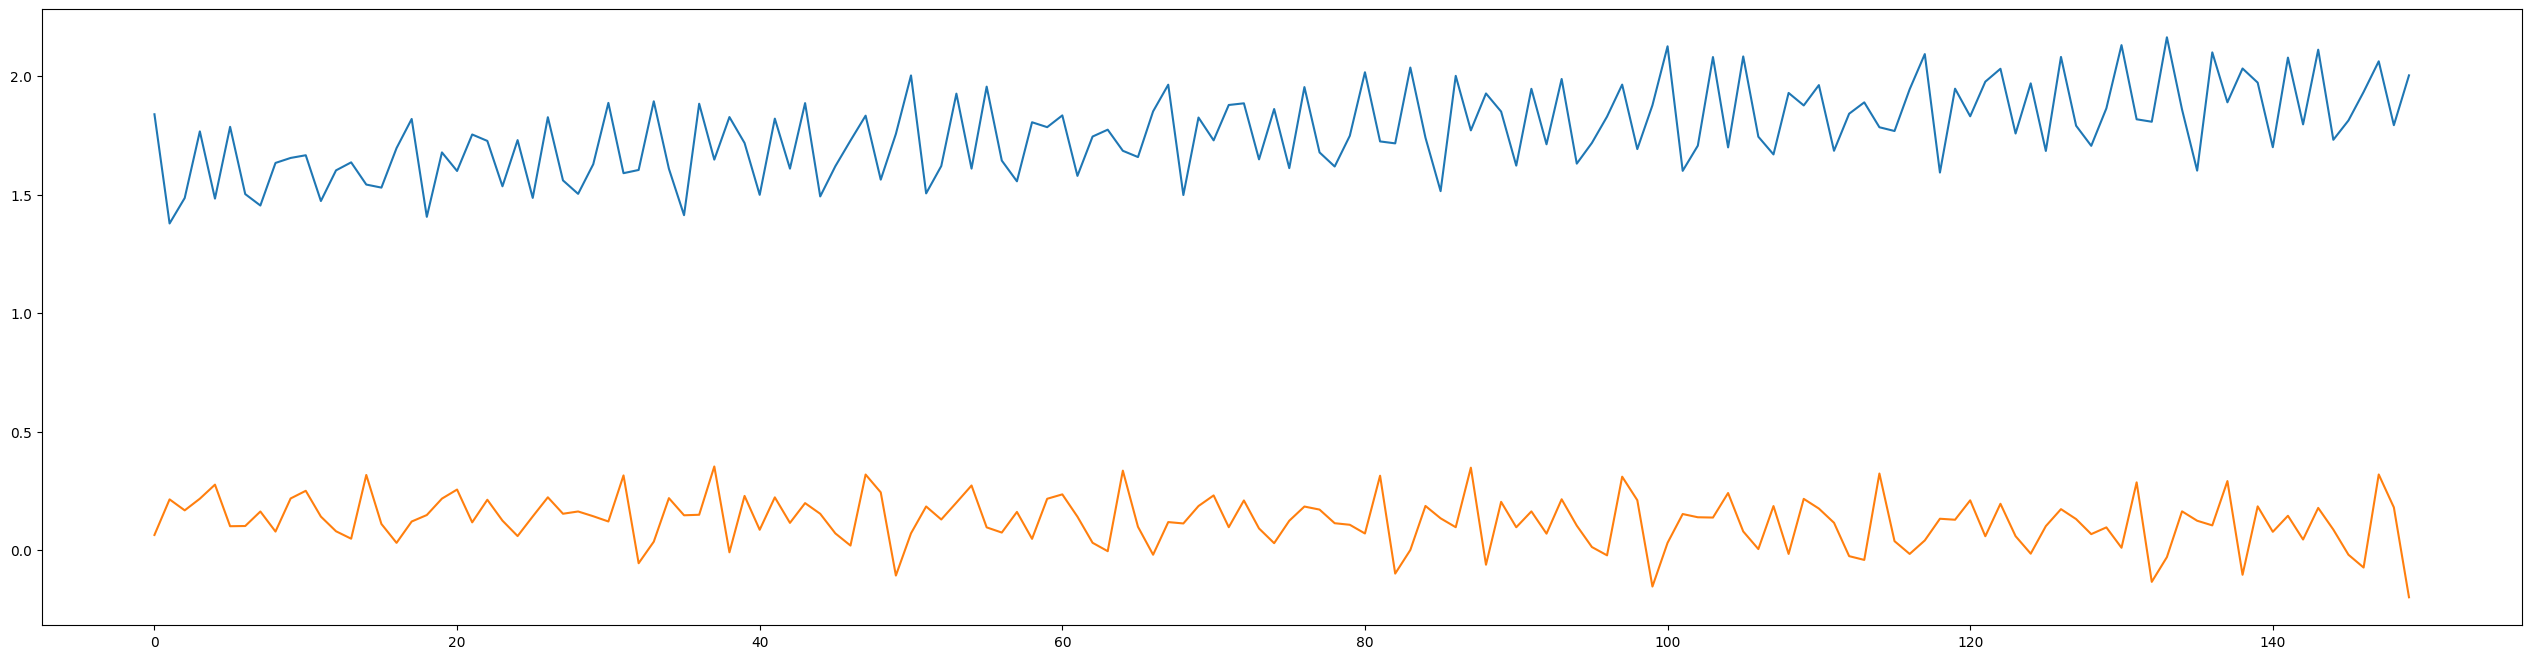

In [58]:
pos_top5_mean_list = []
neg_top5_8_mean_list = []
pos_mv_avg_list = []
neg_mv_avg_list = []
i = 0
mv_avg_num = 100

pos_mv_avg = 0
neg_mv_avg = 0
for log_dict in eval_coeffi_lists:
    i+=1
    score = log_dict["score"]
    pos = score[:5]
    neg = score[5:8]
    pos_top5_mean_list.append(np.mean(pos))
    neg_top5_8_mean_list.append(np.mean(neg))

    pos_mv_avg += np.mean(pos) / mv_avg_num
    neg_mv_avg += np.mean(neg) / mv_avg_num
    if i == mv_avg_num:
        pos_mv_avg_list.append(pos_mv_avg)
        neg_mv_avg_list.append(neg_mv_avg)
        pos_mv_avg = 0
        neg_mv_avg = 0
        i = 0

import matplotlib.pyplot as plt

plt.figure(figsize=(32,8))
# plt.subplot(1,2,1)
plt.plot( pos_top5_mean_list)
# plt.subplot(1,2,2)
plt.plot( neg_top5_8_mean_list)
plt.show()

plt.figure(figsize=(32,8))
# plt.subplot(1,2,1)
plt.plot( pos_mv_avg_list)
# plt.subplot(1,2,2)
plt.plot( neg_mv_avg_list)
plt.show()

#### score distribution

### tta iters折线图 rank0

In [ ]:
import json
import numpy as np
import torch
import torch.nn.functional as F


coeffi_lists = []
for epoch in range(9):
    with open(f"/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.2.3/i2t/20250703210/result/rank0/tta_epoch{epoch}_logging_list.json", "rt") as file:
        # print(type(file))
        coeffi_list_src = json.load(file)
        coeffi_list = json.loads(coeffi_list_src)

    # print(type(coeffi_list))
    print(len(coeffi_list))
    coeffi_lists.extend(coeffi_list)

print(len(coeffi_lists))
print(coeffi_lists[0].keys())
print(len(coeffi_lists[0]['entropy']))

53
53
53
53
53
53
53
53
53
477
dict_keys(['sample_idx', 'label', 'score', 'recall_type', 'sims_i2t', 'idxs_i2t', 'tta_coeffi', 'entropy', 'loss'])
32


#### entropy

In [ ]:
entropy_list = []
mv_avg_entropy_list = []
i = 0
mv_avg_entropy = 0
mv_avg_num = 10

for log_dict in coeffi_lists:
    i += 1
    entropy = np.mean(log_dict["entropy"])
    mv_avg_entropy += entropy / mv_avg_num
    if i == mv_avg_num:
        mv_avg_entropy_list.append(mv_avg_entropy)
        mv_avg_entropy = 0
        i = 0

    entropy_list.append(entropy)

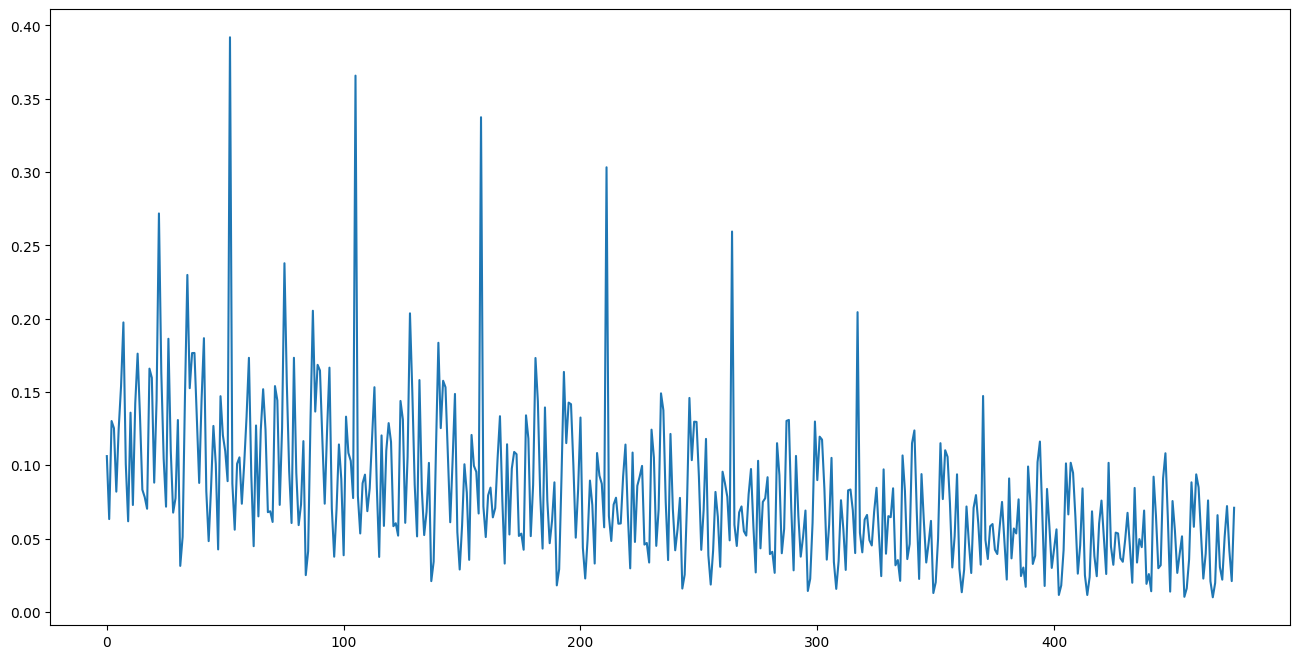

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.plot( entropy_list)
plt.show()

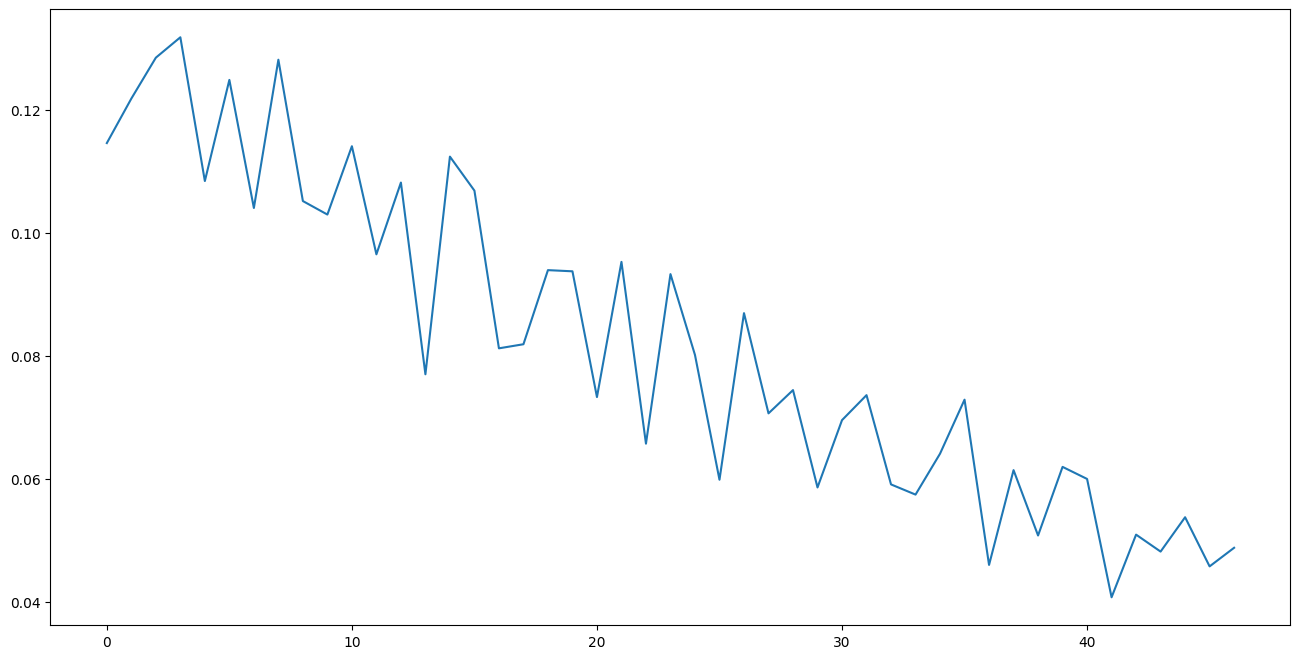

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.plot( mv_avg_entropy_list)
plt.show()

#### loss

In [22]:
loss_list = []
mv_avg_loss_list = []
i = 0
mv_avg_loss = 0
mv_avg_num = 10

for log_dict in coeffi_lists:
    i += 1
    loss = np.mean(log_dict["loss"])
    mv_avg_loss += loss / mv_avg_num
    if i == mv_avg_num:
        mv_avg_loss_list.append(mv_avg_loss)
        mv_avg_loss = 0
        i = 0

    loss_list.append(loss)

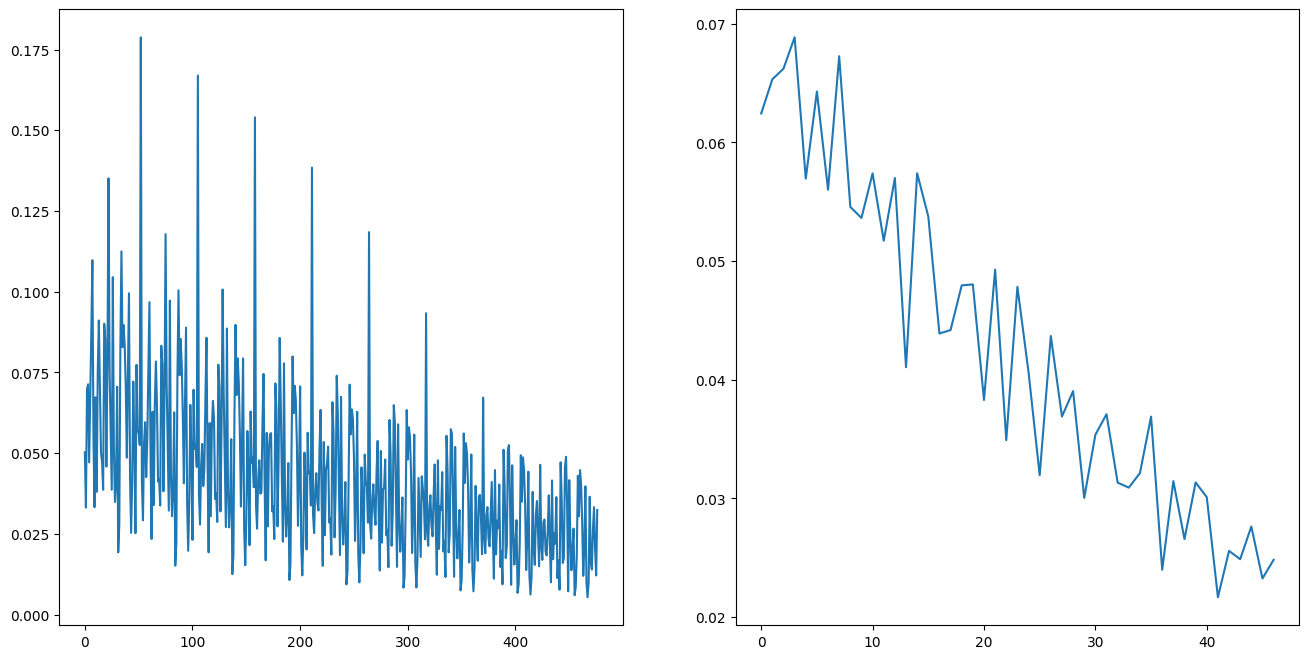

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(loss_list)
plt.subplot(1,2,2)
plt.plot(mv_avg_loss_list)
plt.show()

#### score(pos/neg)

477
15003
15003


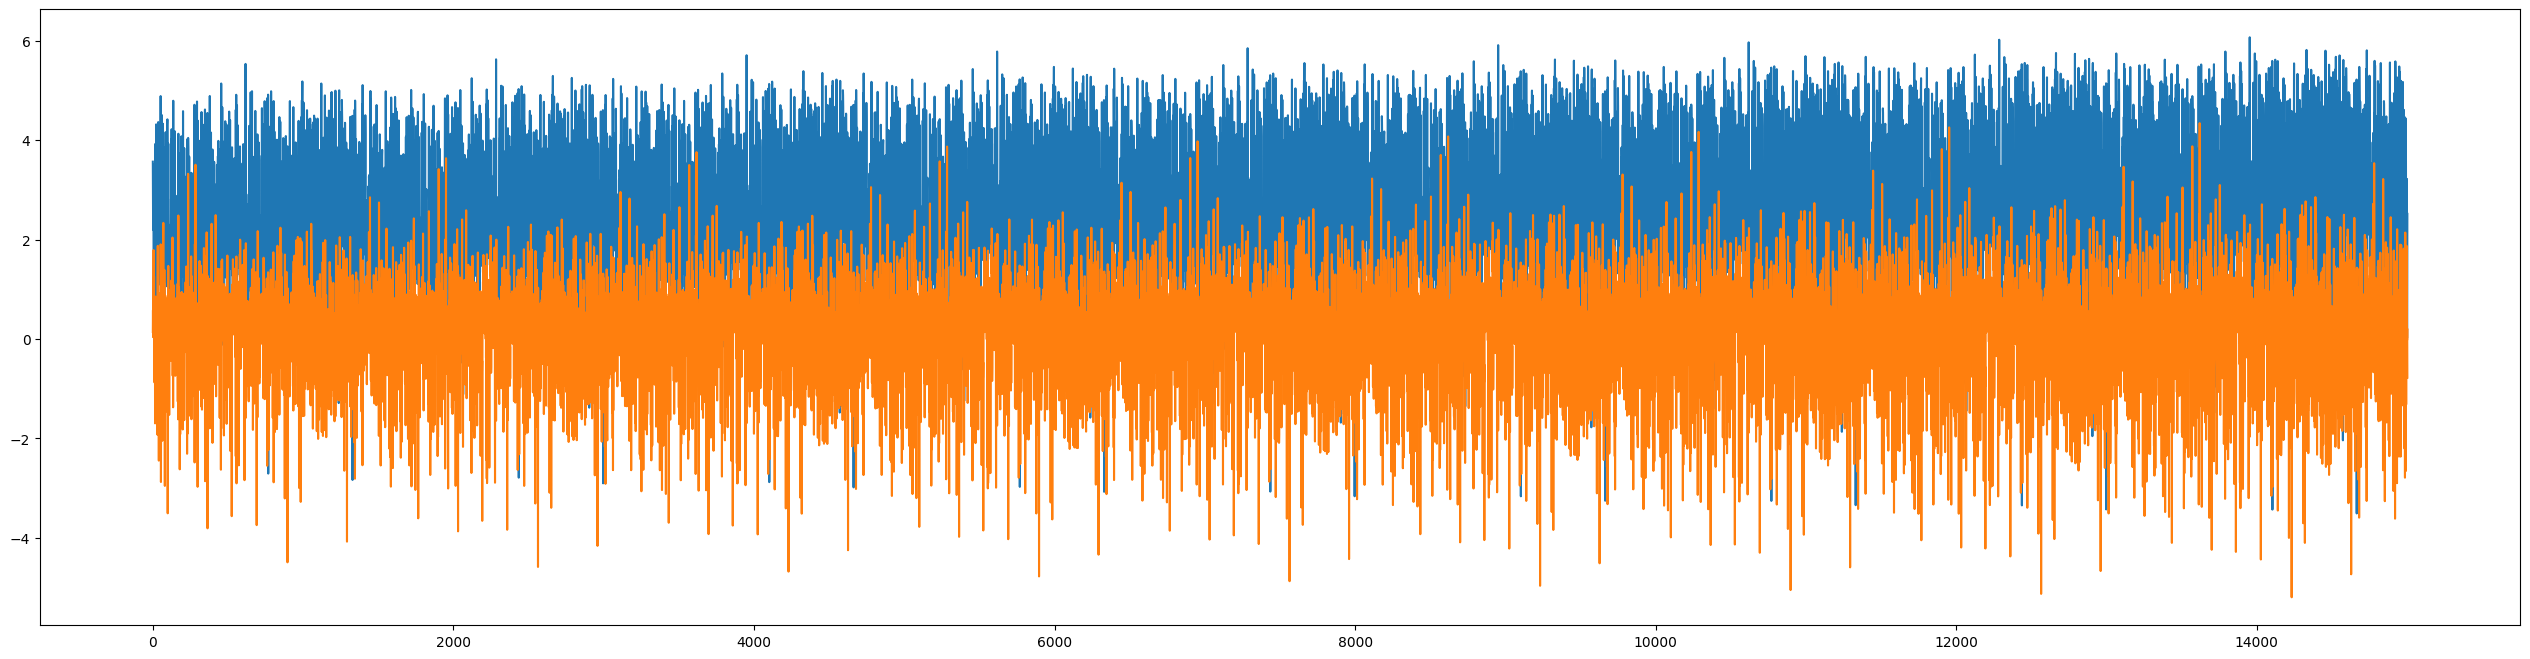

477
477
477


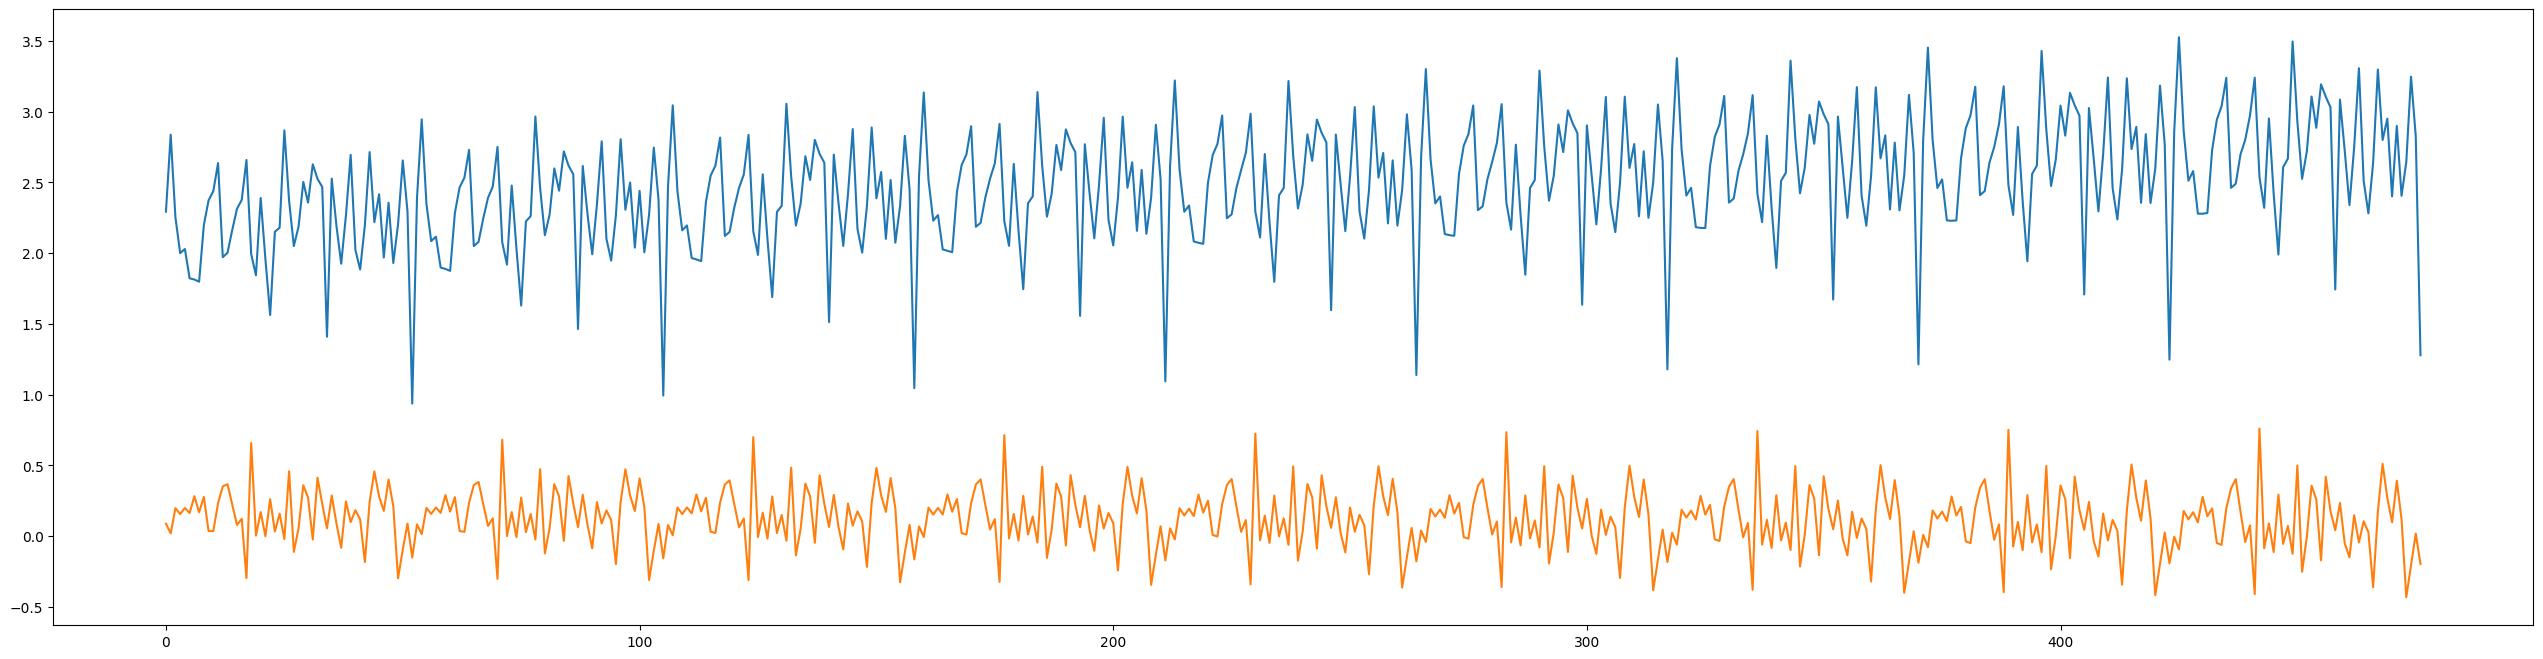

In [39]:
pos_list = []
neg_list = []

pos_batch_mean_score_list = []
neg_batch_mean_score_list = []

for log_dict in coeffi_lists:
    # print(log_dict["score"])
    scores = log_dict["score"]

    poss = [ score[0] for score in scores]
    negs = [ np.mean(score[1:]) for score in scores]
    pos_list.extend(poss)
    neg_list.extend(negs)

    poss_batch_mean_score = np.mean([ score[0] for score in scores])
    negs_batch_mean_score = np.mean([ np.mean(score[1:]) for score in scores])
    pos_batch_mean_score_list.append(poss_batch_mean_score)
    neg_batch_mean_score_list.append(negs_batch_mean_score)

    # break

print(len(coeffi_lists))
print(len(pos_list))
print(len(neg_list))
plt.figure(figsize=(32,8))
# plt.subplot(1,2,1)
plt.plot(pos_list)
# plt.subplot(1,2,2)
plt.plot(neg_list)
plt.show()


print(len(coeffi_lists))
print(len(pos_batch_mean_score_list))
print(len(neg_batch_mean_score_list))
plt.figure(figsize=(32,8))
# plt.subplot(1,2,1)
plt.plot(pos_batch_mean_score_list)
# plt.subplot(1,2,2)
plt.plot(neg_batch_mean_score_list)
plt.show()


## baseline zero-shot

### exp1_visual_log_debug

In [ ]:
json_path = "/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1_visual_log_debug/i2t/20250615062/coeffi_list.json"
with open(json_path, "rt") as file:
    coeffi_list = json.load(file)
    coeffi_list = json.loads(coeffi_list)

print(coeffi_list[0].keys())

In [ ]:
neg_entropy_logits_softmax_list = []
r1_entropy_logits_softmax_list = []
r5_entropy_logits_softmax_list = []
r10_entropy_logits_softmax_list = []

neg_entropy_sigmoid_sum_list = []
r1_entropy_sigmoid_sum_list = []
r5_entropy_sigmoid_sum_list = []
r10_entropy_sigmoid_sum_list = []

neg_entropy_sigmoid_mean_list = []
r1_entropy_sigmoid_mean_list = []
r5_entropy_sigmoid_mean_list = []
r10_entropy_sigmoid_mean_list = []

neg_entropy_softmax_list = []
r1_entropy_softmax_list = []
r5_entropy_softmax_list = []
r10_entropy_softmax_list = []

for coeffi_dict in coeffi_list:
    if coeffi_dict['recall_type'] == "negative sample":
        neg_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        neg_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        neg_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        neg_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@1":
        r1_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r1_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r1_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r1_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@5":
        r5_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r5_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r5_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r5_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@10":
        r10_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r10_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r10_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r10_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])

print("length statistics: neg r1 r5 r10")
print(len(neg_entropy_logits_softmax_list), len(r1_entropy_logits_softmax_list), len(r5_entropy_logits_softmax_list), len(r10_entropy_logits_softmax_list))

print()
print("entropy_logits_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_logits_softmax_list), np.max(neg_entropy_logits_softmax_list), np.min(neg_entropy_logits_softmax_list), np.median(neg_entropy_logits_softmax_list))
print("r1: ", np.mean(r1_entropy_logits_softmax_list), np.max(r1_entropy_logits_softmax_list), np.min(r1_entropy_logits_softmax_list), np.median(r1_entropy_logits_softmax_list))
print("r5: ", np.mean(r5_entropy_logits_softmax_list), np.max(r5_entropy_logits_softmax_list), np.min(r5_entropy_logits_softmax_list), np.median(r5_entropy_logits_softmax_list))
print("r10: ", np.mean(r10_entropy_logits_softmax_list), np.max(r10_entropy_logits_softmax_list), np.min(r10_entropy_logits_softmax_list), np.median(r10_entropy_logits_softmax_list))

print()
print("entropy_sigmoid_sum statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_sum_list), np.max(neg_entropy_sigmoid_sum_list), np.min(neg_entropy_sigmoid_sum_list), np.median(neg_entropy_sigmoid_sum_list))
print("r1: ", np.mean(r1_entropy_sigmoid_sum_list), np.max(r1_entropy_sigmoid_sum_list), np.min(r1_entropy_sigmoid_sum_list), np.median(r1_entropy_sigmoid_sum_list))
print("r5: ", np.mean(r5_entropy_sigmoid_sum_list), np.max(r5_entropy_sigmoid_sum_list), np.min(r5_entropy_sigmoid_sum_list), np.median(r5_entropy_sigmoid_sum_list))
print("r10: ", np.mean(r10_entropy_sigmoid_sum_list), np.max(r10_entropy_sigmoid_sum_list), np.min(r10_entropy_sigmoid_sum_list), np.median(r10_entropy_sigmoid_sum_list))

print()
print("entropy_sigmoid_mean statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_mean_list), np.max(neg_entropy_sigmoid_mean_list), np.min(neg_entropy_sigmoid_mean_list), np.median(neg_entropy_sigmoid_mean_list))
print("r1: ", np.mean(r1_entropy_sigmoid_mean_list), np.max(r1_entropy_sigmoid_mean_list), np.min(r1_entropy_sigmoid_mean_list), np.median(r1_entropy_sigmoid_mean_list))
print("r5: ", np.mean(r5_entropy_sigmoid_mean_list), np.max(r5_entropy_sigmoid_mean_list), np.min(r5_entropy_sigmoid_mean_list), np.median(r5_entropy_sigmoid_mean_list))
print("r10: ", np.mean(r10_entropy_sigmoid_mean_list), np.max(r10_entropy_sigmoid_mean_list), np.min(r10_entropy_sigmoid_mean_list), np.median(r10_entropy_sigmoid_mean_list))

print()
print("entropy_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_softmax_list), np.max(neg_entropy_softmax_list), np.min(neg_entropy_softmax_list), np.median(neg_entropy_softmax_list))
print("r1: ", np.mean(r1_entropy_softmax_list), np.max(r1_entropy_softmax_list), np.min(r1_entropy_softmax_list), np.median(r1_entropy_softmax_list))
print("r5: ", np.mean(r5_entropy_softmax_list), np.max(r5_entropy_softmax_list), np.min(r5_entropy_softmax_list), np.median(r5_entropy_softmax_list))
print("r10: ", np.mean(r10_entropy_softmax_list), np.max(r10_entropy_softmax_list), np.min(r10_entropy_softmax_list), np.median(r10_entropy_softmax_list))


### exp7

In [ ]:
json_path = "/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp7/i2t/20250616193/epoch-1_logging_list.json"
with open(json_path, "rt") as file:
    coeffi_list = json.load(file)
    coeffi_list = json.loads(coeffi_list)

print(coeffi_list[0].keys())

In [ ]:
neg_entropy_logits_softmax_list = []
r1_entropy_logits_softmax_list = []
r5_entropy_logits_softmax_list = []
r10_entropy_logits_softmax_list = []

neg_entropy_sigmoid_sum_list = []
r1_entropy_sigmoid_sum_list = []
r5_entropy_sigmoid_sum_list = []
r10_entropy_sigmoid_sum_list = []

neg_entropy_sigmoid_mean_list = []
r1_entropy_sigmoid_mean_list = []
r5_entropy_sigmoid_mean_list = []
r10_entropy_sigmoid_mean_list = []

neg_entropy_softmax_list = []
r1_entropy_softmax_list = []
r5_entropy_softmax_list = []
r10_entropy_softmax_list = []

for coeffi_dict in coeffi_list:
    if coeffi_dict['recall_type'] == "negative sample":
        neg_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        neg_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        neg_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        neg_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@1":
        r1_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r1_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r1_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r1_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@5":
        r5_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r5_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r5_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r5_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@10":
        r10_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r10_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r10_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r10_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])

print("length statistics: neg r1 r5 r10")
print(len(neg_entropy_logits_softmax_list), len(r1_entropy_logits_softmax_list), len(r5_entropy_logits_softmax_list), len(r10_entropy_logits_softmax_list))

print()
print("entropy_logits_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_logits_softmax_list), np.max(neg_entropy_logits_softmax_list), np.min(neg_entropy_logits_softmax_list), np.median(neg_entropy_logits_softmax_list))
print("r1: ", np.mean(r1_entropy_logits_softmax_list), np.max(r1_entropy_logits_softmax_list), np.min(r1_entropy_logits_softmax_list), np.median(r1_entropy_logits_softmax_list))
print("r5: ", np.mean(r5_entropy_logits_softmax_list), np.max(r5_entropy_logits_softmax_list), np.min(r5_entropy_logits_softmax_list), np.median(r5_entropy_logits_softmax_list))
print("r10: ", np.mean(r10_entropy_logits_softmax_list), np.max(r10_entropy_logits_softmax_list), np.min(r10_entropy_logits_softmax_list), np.median(r10_entropy_logits_softmax_list))

print()
print("entropy_sigmoid_sum statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_sum_list), np.max(neg_entropy_sigmoid_sum_list), np.min(neg_entropy_sigmoid_sum_list), np.median(neg_entropy_sigmoid_sum_list))
print("r1: ", np.mean(r1_entropy_sigmoid_sum_list), np.max(r1_entropy_sigmoid_sum_list), np.min(r1_entropy_sigmoid_sum_list), np.median(r1_entropy_sigmoid_sum_list))
print("r5: ", np.mean(r5_entropy_sigmoid_sum_list), np.max(r5_entropy_sigmoid_sum_list), np.min(r5_entropy_sigmoid_sum_list), np.median(r5_entropy_sigmoid_sum_list))
print("r10: ", np.mean(r10_entropy_sigmoid_sum_list), np.max(r10_entropy_sigmoid_sum_list), np.min(r10_entropy_sigmoid_sum_list), np.median(r10_entropy_sigmoid_sum_list))

print()
print("entropy_sigmoid_mean statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_mean_list), np.max(neg_entropy_sigmoid_mean_list), np.min(neg_entropy_sigmoid_mean_list), np.median(neg_entropy_sigmoid_mean_list))
print("r1: ", np.mean(r1_entropy_sigmoid_mean_list), np.max(r1_entropy_sigmoid_mean_list), np.min(r1_entropy_sigmoid_mean_list), np.median(r1_entropy_sigmoid_mean_list))
print("r5: ", np.mean(r5_entropy_sigmoid_mean_list), np.max(r5_entropy_sigmoid_mean_list), np.min(r5_entropy_sigmoid_mean_list), np.median(r5_entropy_sigmoid_mean_list))
print("r10: ", np.mean(r10_entropy_sigmoid_mean_list), np.max(r10_entropy_sigmoid_mean_list), np.min(r10_entropy_sigmoid_mean_list), np.median(r10_entropy_sigmoid_mean_list))

print()
print("entropy_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_softmax_list), np.max(neg_entropy_softmax_list), np.min(neg_entropy_softmax_list), np.median(neg_entropy_softmax_list))
print("r1: ", np.mean(r1_entropy_softmax_list), np.max(r1_entropy_softmax_list), np.min(r1_entropy_softmax_list), np.median(r1_entropy_softmax_list))
print("r5: ", np.mean(r5_entropy_softmax_list), np.max(r5_entropy_softmax_list), np.min(r5_entropy_softmax_list), np.median(r5_entropy_softmax_list))
print("r10: ", np.mean(r10_entropy_softmax_list), np.max(r10_entropy_softmax_list), np.min(r10_entropy_softmax_list), np.median(r10_entropy_softmax_list))


# zero-shot 负样本采样 score.show()

## top1和其余15个负样本的差异
- batch = pos(top1) + neg(15 * sampling from top32~128)

### top(32,128) one sample

In [1]:
import torch
import torch.nn.functional as F

score_32_128 = torch.Tensor([[ 3.5667, -2.8287, -6.3197, -4.7724, -2.6105, -3.2053, -4.2531, -4.4329,
         -3.9197, -3.1590, -5.6936, -3.6822, -1.2667, -2.8792, -2.8216, -1.0740],
        [ 2.5099, -4.1357, -5.4952, -3.1999, -6.0585, -1.2038, -3.8756, -2.7068,
         -2.1692, -2.5481, -4.3602, -0.8354, -3.6226, -4.9880, -5.4860, -0.8545],
        [ 2.1975, -1.4912, -1.6474, -2.5968, -3.1348, -1.1771, -1.7994, -5.1716,
         -1.4218, -2.7125, -0.1381, -0.4673, -0.2047, -1.2380, -0.2625, -4.2207],
        [ 3.0514, -2.6248, -0.5111, -1.3498, -1.2535, -2.4860, -1.3664, -1.5828,
         -1.4646, -2.5590, -2.7638, -3.0482, -3.8081, -4.1487, -1.8235, -1.8222],
        [ 3.0197, -3.4594, -4.7157, -5.9915, -4.4762, -5.4324, -5.1149, -3.4077,
         -5.2341, -3.6322, -4.8053, -6.3458, -3.0771, -1.0846, -6.7638, -4.2946],
        [ 2.2184, -5.9113, -1.1773, -0.6776, -5.6835, -2.0352, -1.2113, -5.8816,
         -1.2113, -5.9439, -5.5331, -3.7744, -5.2804, -6.1658, -3.0847, -6.8215],
        [ 1.8080, -0.4717, -0.9795, -0.6314, -0.4442,  0.0852, -0.5305, -1.2425,
         -0.1826, -3.1122, -0.5502, -0.1762, -0.2559, -0.1787, -0.5581, -0.5875],
        [ 0.8276, -0.8725, -0.3617, -0.4739, -0.4370, -3.5637, -1.7056, -0.2597,
         -1.0400, -1.2157, -0.5729, -0.6318, -3.0906, -1.2979, -0.9477, -0.3276]],)

proba = F.softmax(score_32_128 , dim=-1)
entropy = -(F.softmax(score_32_128 , dim=-1) * F.log_softmax(score_32_128 , dim=-1)).sum(-1)

# entropy =tensor([0.1864, 0.5617, 1.4233, 0.5962, 0.1572, 0.6887, 2.2401, 2.4491],)

In [2]:
entropy.mean()

tensor(1.0378)

In [3]:
# proba = tensor([[9.7147e-01, 1.6216e-03, 4.9411e-05, 2.3217e-04, 2.0170e-03, 1.1127e-03,
                #  3.9024e-04, 3.2602e-04, 5.4466e-04, 1.1655e-03, 9.2413e-05, 6.9068e-04,
                #  7.7324e-03, 1.5417e-03, 1.6332e-03, 9.3756e-03],
                # [8.8793e-01, 1.1541e-03, 2.9635e-04, 2.9420e-03, 1.6872e-04, 2.1654e-02,
                #  1.4969e-03, 4.8172e-03, 8.2465e-03, 5.6457e-03, 9.2200e-04, 3.1299e-02,
                #  1.9278e-03, 4.9213e-04, 2.9909e-04, 3.0707e-02],
                # [6.5657e-01, 1.6417e-02, 1.4043e-02, 5.4343e-03, 3.1732e-03, 2.2476e-02,
                #  1.2063e-02, 4.1392e-04, 1.7597e-02, 4.8405e-03, 6.3525e-02, 4.5706e-02,
                #  5.9432e-02, 2.1148e-02, 5.6094e-02, 1.0713e-03],
                # [8.9272e-01, 3.0590e-03, 2.5325e-02, 1.0947e-02, 1.2054e-02, 3.5144e-03,
                #  1.0767e-02, 8.6718e-03, 9.7599e-03, 3.2670e-03, 2.6620e-03, 2.0031e-03,
                #  9.3686e-04, 6.6643e-04, 6.8167e-03, 6.8256e-03],
                # [9.7439e-01, 1.4959e-03, 4.2588e-04, 1.1891e-04, 5.4113e-04, 2.0798e-04,
                #  2.8571e-04, 1.5752e-03, 2.5360e-04, 1.2585e-03, 3.8938e-04, 8.3435e-05,
                #  2.1924e-03, 1.6079e-02, 5.4930e-05, 6.4889e-04],
                # [8.4902e-01, 2.5017e-04, 2.8457e-02, 4.6903e-02, 3.1417e-04, 1.2067e-02,
                #  2.7506e-02, 2.5771e-04, 2.7506e-02, 2.4215e-04, 3.6516e-04, 2.1197e-03,
                #  4.7015e-04, 1.9396e-04, 4.2249e-03, 1.0068e-04],
                # [3.9941e-01, 4.0865e-02, 2.4593e-02, 3.4834e-02, 4.2005e-02, 7.1320e-02,
                #  3.8532e-02, 1.8906e-02, 5.4564e-02, 2.9147e-03, 3.7780e-02, 5.4915e-02,
                #  5.0708e-02, 5.4778e-02, 3.7483e-02, 3.6397e-02],
                # [2.5926e-01, 4.7358e-02, 7.8928e-02, 7.0551e-02, 7.3203e-02, 3.2109e-03,
                #  2.0587e-02, 8.7404e-02, 4.0054e-02, 3.3600e-02, 6.3901e-02, 6.0246e-02,
                #  5.1533e-03, 3.0949e-02, 4.3927e-02, 8.1666e-02]])

In [4]:
print("max min mean median std ")
print(proba.max(), proba.min(), proba.mean(), proba.median(), proba.std())
print("neg.max neg.min neg.mean neg.median neg.std")
print(proba[:, 1:].max(), proba[:, 1:].min(), proba[:, 1:].mean(), proba[:, 1:].median(), proba[:, 1:].std())

max min mean median std 
tensor(0.9744) tensor(4.9411e-05) tensor(0.0625) tensor(0.0068) tensor(0.1873)
neg.max neg.min neg.mean neg.median neg.std
tensor(0.0874) tensor(4.9411e-05) tensor(0.0176) tensor(0.0048) tensor(0.0227)


### top(10,32) one sample

In [5]:
score = torch.Tensor([[ 3.5667e+00, -6.9058e-01, -4.1775e-01, -1.6234e+00,  1.1297e-01,
         -6.5784e-02, -2.5333e+00, -5.4269e-01, -1.2514e+00, -2.1594e+00,
          3.6940e-02, -6.5690e-01, -4.7195e+00, -2.1366e+00, -3.3198e+00,
          1.6008e-02],
        [ 2.5099e+00, -2.3676e+00, -1.1363e+00, -1.4455e+00, -4.4448e+00,
         -3.5131e+00, -2.9808e+00, -5.7891e-01, -1.9893e+00, -1.8585e+00,
         -5.8675e-01, -1.6773e+00, -3.0267e+00, -4.9869e+00, -3.0792e+00,
         -7.8207e-01],
        [ 2.1975e+00, -4.9136e-01, -6.2768e-01, -1.5989e+00, -1.5761e+00,
         -2.6872e+00, -1.3661e+00, -3.8252e+00, -2.2036e+00, -2.1952e+00,
         -8.2297e-01, -8.6833e-01, -9.7158e-01, -1.5473e+00, -3.3040e-01,
         -1.3729e+00],
        [ 3.0514e+00, -1.1324e+00, -1.5955e-01, -9.5334e-01,  2.4388e-03,
          2.9186e-02,  1.2899e-02,  4.5299e-01, -9.2271e-01, -1.3789e-01,
         -1.5055e-01, -1.7621e+00, -1.2162e+00, -3.0868e+00,  1.4442e-01,
          1.0188e-01],
        [ 3.0197e+00, -1.3416e+00, -1.3108e+00, -3.8227e+00, -2.2672e+00,
         -1.0626e+00, -1.3416e+00, -1.1635e+00, -1.4005e+00, -5.7134e+00,
         -1.3108e+00, -3.8252e+00, -4.7621e+00, -5.6966e+00, -1.3416e+00,
         -2.0278e+00],
        [ 2.2184e+00, -1.1491e+00, -4.1854e+00, -5.1513e+00, -5.6259e+00,
         -1.0168e+00, -2.5251e+00, -4.9787e+00, -3.1128e+00, -6.1040e+00,
         -2.9205e+00, -6.0969e+00, -5.9738e+00, -3.5540e+00, -5.5696e-01,
         -2.6209e+00],
        [ 1.8080e+00,  2.5629e-01,  1.5640e-01,  3.1635e-01,  1.1531e-01,
          5.7262e-01,  3.2249e-01,  1.5664e-01,  1.8648e-02,  6.6248e-02,
          1.8443e-01,  1.2287e+00, -1.1920e-01, -6.9018e-03, -7.3227e-01,
          8.5291e-02],
        [ 8.2762e-01, -3.6459e-01,  7.3355e-01, -1.3814e+00, -5.0589e-01,
         -6.3823e-01, -1.2063e+00, -1.8245e-01, -1.2114e-01, -1.1181e-01,
         -4.5947e-01,  5.4648e-02, -1.3585e+00, -6.6610e-02,  5.1530e-02,
         -3.1865e-01]],)

proba = F.softmax(score , dim=-1)
entropy = -(F.softmax(score , dim=-1) * F.log_softmax(score , dim=-1)).sum(-1)
# tensor([0.8523, 0.9163, 1.4701, 1.5096, 0.6028, 0.6701, 2.5396, 2.5951],

In [6]:
entropy.mean()

tensor(1.3945)

In [7]:
proba

tensor([[8.3078e-01, 1.1765e-02, 1.5455e-02, 4.6287e-03, 2.6275e-02, 2.1974e-02,
         1.8633e-03, 1.3640e-02, 6.7145e-03, 2.7082e-03, 2.4352e-02, 1.2167e-02,
         2.0933e-04, 2.7706e-03, 8.4863e-04, 2.3847e-02],
        [8.0938e-01, 6.1643e-03, 2.1117e-02, 1.5501e-02, 7.7227e-04, 1.9606e-03,
         3.3387e-03, 3.6872e-02, 8.9986e-03, 1.0256e-02, 3.6584e-02, 1.2294e-02,
         3.1889e-03, 4.4909e-04, 3.0258e-03, 3.0093e-02],
        [6.6459e-01, 4.5165e-02, 3.9409e-02, 1.4921e-02, 1.5265e-02, 5.0253e-03,
         1.8832e-02, 1.6104e-03, 8.1505e-03, 8.2192e-03, 3.2418e-02, 3.0980e-02,
         2.7941e-02, 1.5711e-02, 5.3052e-02, 1.8705e-02],
        [6.5610e-01, 9.9992e-03, 2.6453e-02, 1.1960e-02, 3.1104e-02, 3.1947e-02,
         3.1431e-02, 4.8808e-02, 1.2332e-02, 2.7032e-02, 2.6692e-02, 5.3271e-03,
         9.1954e-03, 1.4164e-03, 3.5849e-02, 3.4356e-02],
        [8.9038e-01, 1.1363e-02, 1.1718e-02, 9.5052e-04, 4.5030e-03, 1.5019e-02,
         1.1363e-02, 1.3578e-02, 1.0713

In [8]:
print("max min mean median std ")
print(proba.max(), proba.min(), proba.mean(), proba.median(), proba.std())
print("neg.max neg.min neg.mean neg.median neg.std")
print(proba[:, 1:].max(), proba[:, 1:].min(), proba[:, 1:].mean(), proba[:, 1:].median(), proba[:, 1:].std())

max min mean median std 
tensor(0.8904) tensor(0.0001) tensor(0.0625) tensor(0.0183) tensor(0.1652)
neg.max neg.min neg.mean neg.median neg.std
tensor(0.1485) tensor(0.0001) tensor(0.0241) tensor(0.0155) tensor(0.0250)


top32~128 proba:  
max min mean median std   
tensor(0.9744) tensor(4.9411e-05) tensor(0.0625) tensor(0.0068) tensor(0.1873)  
neg.max neg.min neg.mean neg.median neg.std  
tensor(0.0874) tensor(4.9411e-05) tensor(0.0176) tensor(0.0048) tensor(0.0227)  

top10~32 proba:  
max min mean median std   
tensor(0.8904) tensor(0.0001) tensor(0.0625) tensor(0.0183) tensor(0.1652)  
neg.max neg.min neg.mean neg.median neg.std  
tensor(0.1485) tensor(0.0001) tensor(0.0241) tensor(0.0155) tensor(0.0250)  

## i2t/t2i all score analysis

In [79]:
import json
import numpy as np
import torch
import torch.nn.functional as F

In [80]:
## zero-shot top128 score

with open("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.1/i2t/20250624151/result/rank0_eval_epoch-1_logging_list.json", "rt") as file:
    print(type(file))
    score_i2t_str = json.load(file)
    score_i2t = json.loads(score_i2t_str)

# score_t2i = with open("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.1/t2i/*********/result/rank0_eval_epoch-1_logging_list.json", "rt") as file:
#     print(type(file))
#     score_t2i_str = json.load(file)
#     score_t2i = json.loads(score_t2i_str)

<class '_io.TextIOWrapper'>


In [81]:
print(f"number of i2t samples : {len(score_i2t)}")

number of i2t samples : 5000


In [82]:
print(f"score_i2t[0].keys() : {score_i2t[0].keys()}")
print(f"score_i2t[0]['recall_type'] : {score_i2t[0]['recall_type'] }")
print(f"score_i2t[0]['topk_sim'] : {len(score_i2t[0]['topk_sim']) }")
print(f"score_i2t[0]['score'] : {len(score_i2t[0]['score'])  }")
print(f"score_i2t[0]['top128_entropy'] : {score_i2t[0]['entropy'] }")
# print(f"score_i2t[0]['recall_type'] : {score_i2t[0]['recall_type'] }")

score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
score_i2t[0]['recall_type'] : recall@1
score_i2t[0]['topk_sim'] : 128
score_i2t[0]['score'] : 128
score_i2t[0]['top128_entropy'] : 2.258613348007202


### zero-shot

In [83]:
def show_score_stats(score_i2t):
    neg_topk_sim_list = []
    r1_topk_sim_list = []
    r5_topk_sim_list = []
    r10_topk_sim_list = []

    neg_score_list = []
    r1_score_list = []
    r5_score_list = []
    r10_score_list = []

    neg_entropy_list = []
    r1_entropy_list = []
    r5_entropy_list = []
    r10_entropy_list = []

    for score_dict in score_i2t:
        if score_dict['recall_type'] == "negative sample":
            neg_topk_sim_list.append(score_dict["topk_sim"])
            neg_score_list.append(score_dict["score"])
            neg_entropy_list.append(score_dict["entropy"])
        elif score_dict['recall_type'] == "recall@1":
            r1_topk_sim_list.append(score_dict["topk_sim"])
            r1_score_list.append(score_dict["score"])
            r1_entropy_list.append(score_dict["entropy"])
        elif score_dict['recall_type'] == "recall@5":
            r5_topk_sim_list.append(score_dict["topk_sim"])
            r5_score_list.append(score_dict["score"])
            r5_entropy_list.append(score_dict["entropy"])
        elif score_dict['recall_type'] == "recall@10":
            r10_topk_sim_list.append(score_dict["topk_sim"])
            r10_score_list.append(score_dict["score"])
            r10_entropy_list.append(score_dict["entropy"])

    print("length statistics: neg r1 r5 r10")
    print(len(neg_entropy_list), len(r1_entropy_list), len(r5_entropy_list), len(r10_entropy_list))

    print()
    print("topk_sim statistics: mean max min median")
    print("neg: ", np.mean(neg_topk_sim_list), np.max(neg_topk_sim_list), np.min(neg_topk_sim_list), np.median(neg_topk_sim_list))
    print("r1: ", np.mean(r1_topk_sim_list), np.max(r1_topk_sim_list), np.min(r1_topk_sim_list), np.median(r1_topk_sim_list))
    print("r5: ", np.mean(r5_topk_sim_list), np.max(r5_topk_sim_list), np.min(r5_topk_sim_list), np.median(r5_topk_sim_list))
    print("r10: ", np.mean(r10_topk_sim_list), np.max(r10_topk_sim_list), np.min(r10_topk_sim_list), np.median(r10_topk_sim_list))

    print()
    print("score statistics: mean max min median")
    print("neg: ", np.mean(neg_score_list), np.max(neg_score_list), np.min(neg_score_list), np.median(neg_score_list))
    print("r1: ",np.mean(r1_score_list), np.max(r1_score_list), np.min(r1_score_list), np.median(r1_score_list))
    print("r5: ", np.mean(r5_score_list), np.max(r5_score_list), np.min(r5_score_list), np.median(r5_score_list))
    print("r10: ", np.mean(r10_score_list), np.max(r10_score_list), np.min(r10_score_list), np.median(r10_score_list))

    print()
    print("entropy statistics: mean max min median")
    print("neg: ", np.mean(neg_entropy_list), np.max(neg_entropy_list), np.min(neg_entropy_list), np.median(neg_entropy_list))
    print("r1: ",np.mean(r1_entropy_list), np.max(r1_entropy_list), np.min(r1_entropy_list), np.median(r1_entropy_list))
    print("r5: ", np.mean(r5_entropy_list), np.max(r5_entropy_list), np.min(r5_entropy_list), np.median(r5_entropy_list))
    print("r10: ", np.mean(r10_entropy_list), np.max(r10_entropy_list), np.min(r10_entropy_list), np.median(r10_entropy_list))


In [84]:
show_score_stats(score_i2t)

length statistics: neg r1 r5 r10
129 3719 992 160

topk_sim statistics: mean max min median
neg:  0.45498764363131955 0.5569778084754944 0.3479570746421814 0.45595912635326385
r1:  0.40107592666330344 0.6125096678733826 0.29702228307724 0.39300617575645447
r5:  0.4239975187581055 0.5953502058982849 0.3045620620250702 0.42081499099731445
r10:  0.44136907769425304 0.5820091366767883 0.32159551978111267 0.44188548624515533

score statistics: mean max min median
neg:  -0.5634530126257895 3.062492847442627 -6.772589206695557 -0.27657903730869293
r1:  -2.2508195916908176 5.611236572265625 -7.543262481689453 -2.1215819120407104
r5:  -1.5417760368244828 4.86556339263916 -7.369493007659912 -1.1519781351089478
r10:  -0.9630478420171016 4.1121392250061035 -7.233804702758789 -0.5411417782306671

entropy statistics: mean max min median
neg:  4.635891942090766 4.8412394523620605 3.362489700317383 4.731634140014648
r1:  3.0667954509570476 4.836906909942627 1.1115614175796509 3.0329437255859375
r5:  3

### top32-128

In [85]:
## 负样本采样方法
def sample_neg_idxs(sims_matrix_i2t, k_tta, k_test, neg_sample_range=[32, 128]):
    num_images, num_texts = sims_matrix_i2t.shape
    neg_idxs = []
    neg_sims = []
    for i in range(num_images):
        topk_sim_i2t, topk_idx_i2t = sims_matrix_i2t[i].topk(k=k_test, dim=0)
        # random_idx = torch.randperm(k_test-2*k_tta)[:k_tta-1] + 2*k_tta # 随机采样k_tta-1个负样本索引
        random_idx = torch.randperm(neg_sample_range[1] - neg_sample_range[0])[:k_tta-1] + neg_sample_range[0]
        # print(random_idx)
        neg_sims.append(topk_sim_i2t[random_idx])
        neg_idxs.append(topk_idx_i2t[random_idx])
    return torch.stack(neg_sims, dim=0), torch.stack(neg_idxs, dim=0)



In [86]:
sims_matrix_i2t = torch.from_numpy(np.load("debugs/debug_sim_matrix_i2t.npy"))

In [87]:
## 正样本取top1
top1_sims, top1_idxs = sims_matrix_i2t.topk(k=1, dim=1) #正样本直接使用top1 TODO 使用top5采样一个正样本？
top1_sims, top1_idxs =top1_sims[:,0], top1_idxs[:,0]
print(top1_idxs.shape)
print(top1_idxs[0])

## 负样本取top32-128采样15个
neg_sims, neg_idxs = sample_neg_idxs(sims_matrix_i2t, 16, 128, neg_sample_range=[32, 128])
print(neg_idxs.shape)
print(neg_idxs[0])

torch.Size([5000])
tensor(4)
torch.Size([5000, 15])
tensor([15787,    13, 19332, 15774, 18756,  5674, 22294,  5700, 15771,  5681,
        15346, 18525,  5698,    61, 11823])


In [88]:
## 拼接正负样本至同一个sample
sampled_sims_matrix_i2t = []
sampled_sims_idx_i2t = []
for i in range(sims_matrix_i2t.size(0)):
    sampled_sim = torch.concatenate((sims_matrix_i2t[i,top1_idxs[i]].reshape(-1), sims_matrix_i2t[i,neg_idxs[i]]))
    sampled_idx = torch.concatenate((top1_idxs[i].reshape(-1), neg_idxs[i]))
    sampled_sims_matrix_i2t.append(sampled_sim)
    sampled_sims_idx_i2t.append(sampled_idx)
sampled_sims_matrix_i2t = torch.stack(sampled_sims_matrix_i2t) # shape=(5000, k_tta)
sampled_sims_idx_i2t = torch.stack(sampled_sims_idx_i2t) # shape=(5000, k_tta)

In [89]:
## 采样后show sample
print(sampled_sims_matrix_i2t.shape)
print(sampled_sims_matrix_i2t[0])
print()
print(sampled_sims_idx_i2t.shape)
print(sampled_sims_idx_i2t[0])

torch.Size([5000, 16])
tensor([0.5555, 0.4142, 0.3664, 0.3760, 0.3850, 0.4119, 0.3773, 0.3676, 0.3992,
        0.3865, 0.4222, 0.3901, 0.3696, 0.4081, 0.3683, 0.3994])

torch.Size([5000, 16])
tensor([    4, 15787,    13, 19332, 15774, 18756,  5674, 22294,  5700, 15771,
         5681, 15346, 18525,  5698,    61, 11823])


In [ ]:
## 使用上述采样后的index，在score_dict中找到对应的score
sampled_score_i2t = []
for score_dict, sampled_sims_idx in zip(score_i2t, sampled_sims_idx_i2t):
    # score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
    sampled_idx = []
    sampled_sim = []
    sampled_score = []
    # print(sampled_sims_idx)
    for idx, sim, score in zip(score_dict["topk_idx"], score_dict["topk_sim"], score_dict["score"]):
        if idx in sampled_sims_idx:
            # print(idx)
            # print(sim)
            # print(score)
            sampled_idx.append(idx)
            sampled_sim.append(sim)
            sampled_score.append(score)
    score_dict_sampled = {
        'recall_type': score_dict["recall_type"],
        'label': score_dict["label"],
        'topk_sim': sampled_sim,
        'topk_idx': sampled_idx,
        'score': sampled_score,
    }
    sampled_score_i2t.append(score_dict_sampled)

    # break

In [91]:
print(f"len(sampled_score_i2t) : {len(sampled_score_i2t)}")
print(f"sampled_score_i2t[0].keys() : {sampled_score_i2t[0].keys()}")
print(f"sampled_score_i2t[0]['recall_type'] : {sampled_score_i2t[0]['recall_type']}")
print(f"sampled_score_i2t[0]['topk_sim'] : {sampled_score_i2t[0]['topk_sim']}")
print(f"sampled_score_i2t[0]['topk_idx'] : {sampled_score_i2t[0]['topk_idx']}")
print(f"sampled_score_i2t[0]['score'] : {sampled_score_i2t[0]['score']}")

len(sampled_score_i2t) : 5000
sampled_score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t[0]['recall_type'] : recall@1
sampled_score_i2t[0]['topk_sim'] : [0.5554964542388916, 0.422233521938324, 0.4141978919506073, 0.4119354784488678, 0.4080696702003479, 0.39936530590057373, 0.3992215394973755, 0.3900560140609741, 0.38652247190475464, 0.38500872254371643, 0.37725046277046204, 0.3760238289833069, 0.3696247339248657, 0.36830225586891174, 0.36757680773735046, 0.36636778712272644]
sampled_score_i2t[0]['topk_idx'] : [4, 5681, 15787, 18756, 5698, 11823, 5700, 15346, 15771, 15774, 5674, 19332, 18525, 61, 22294, 13]
sampled_score_i2t[0]['score'] : [3.5666849613189697, -1.7642648220062256, -3.3512492179870605, -2.9987831115722656, -3.96278715133667, -2.8201241493225098, -2.2256696224212646, -4.336810111999512, -4.677213191986084, -4.744818687438965, -1.4223765134811401, -4.469921112060547, -3.9197466373443604, -4.237922668457031, -4.497988

### top10-32

In [92]:
neg_sample_range = [10, 32]

In [93]:
## 正样本取top1
top1_sims, top1_idxs = sims_matrix_i2t.topk(k=1, dim=1) #正样本直接使用top1 TODO 使用top5采样一个正样本？
top1_sims, top1_idxs =top1_sims[:,0], top1_idxs[:,0]
print(top1_idxs.shape)
print(top1_idxs[0])

## 负样本取top32-128采样15个
neg_sims, neg_idxs = sample_neg_idxs(sims_matrix_i2t, 16, 128, neg_sample_range=neg_sample_range)
print(neg_idxs.shape)
print(neg_idxs[0])

## 拼接正负样本至同一个sample
sampled_sims_matrix_i2t_10_32 = []
sampled_sims_idx_i2t_10_32 = []
for i in range(sims_matrix_i2t.size(0)):
    sampled_sim = torch.concatenate((sims_matrix_i2t[i,top1_idxs[i]].reshape(-1), sims_matrix_i2t[i,neg_idxs[i]]))
    sampled_idx = torch.concatenate((top1_idxs[i].reshape(-1), neg_idxs[i]))
    sampled_sims_matrix_i2t_10_32.append(sampled_sim)
    sampled_sims_idx_i2t_10_32.append(sampled_idx)
sampled_sims_matrix_i2t_10_32 = torch.stack(sampled_sims_matrix_i2t_10_32) # shape=(5000, k_tta)
sampled_sims_idx_i2t_10_32 = torch.stack(sampled_sims_idx_i2t_10_32) # shape=(5000, k_tta)

## 采样后show sample
print(sampled_sims_matrix_i2t_10_32.shape)
print(sampled_sims_matrix_i2t_10_32[0])
print()
print(sampled_sims_idx_i2t_10_32.shape)
print(sampled_sims_idx_i2t_10_32[0])

torch.Size([5000])
tensor(4)
torch.Size([5000, 15])
tensor([13805, 23560, 10014, 10035, 19860,  7431,  7430, 13784, 11861, 15773,
        15789, 13786, 15788, 18523, 19865])
torch.Size([5000, 16])
tensor([0.5555, 0.4693, 0.4647, 0.4288, 0.4358, 0.4258, 0.4513, 0.4336, 0.4343,
        0.4648, 0.4255, 0.4741, 0.4275, 0.4768, 0.4324, 0.4288])

torch.Size([5000, 16])
tensor([    4, 13805, 23560, 10014, 10035, 19860,  7431,  7430, 13784, 11861,
        15773, 15789, 13786, 15788, 18523, 19865])


In [ ]:
## 使用上述采样后的index，在score_dict中找到对应的score
sampled_score_i2t_10_32 = []
for score_dict, sampled_sims_idx in zip(score_i2t, sampled_sims_idx_i2t_10_32):
    # score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
    sampled_idx = []
    sampled_sim = []
    sampled_score = []
    # print(sampled_sims_idx)
    for idx, sim, score in zip(score_dict["topk_idx"], score_dict["topk_sim"], score_dict["score"]):
        if idx in sampled_sims_idx:
            # print(idx)
            # print(sim)
            # print(score)
            sampled_idx.append(idx)
            sampled_sim.append(sim)
            sampled_score.append(score)
    score_dict_sampled = {
        'recall_type': score_dict["recall_type"],
        'label': score_dict["label"],
        'topk_sim': sampled_sim,
        'topk_idx': sampled_idx,
        'score': sampled_score,
    }
    sampled_score_i2t_10_32.append(score_dict_sampled)

    # break


In [95]:
print(f"len(sampled_score_i2t_10_32) : {len(sampled_score_i2t_10_32)}")
print(f"sampled_score_i2t_10_32[0].keys() : {sampled_score_i2t_10_32[0].keys()}")
print(f"sampled_score_i2t_10_32[0]['recall_type'] : {sampled_score_i2t_10_32[0]['recall_type']}")
print(f"sampled_score_i2t_10_32[0]['topk_sim'] : {sampled_score_i2t_10_32[0]['topk_sim']}")
print(f"sampled_score_i2t_10_32[0]['topk_idx'] : {sampled_score_i2t_10_32[0]['topk_idx']}")
print(f"sampled_score_i2t_10_32[0]['score'] : {sampled_score_i2t_10_32[0]['score']}")

len(sampled_score_i2t_10_32) : 5000
sampled_score_i2t_10_32[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t_10_32[0]['recall_type'] : recall@1
sampled_score_i2t_10_32[0]['topk_sim'] : [0.5554964542388916, 0.47681427001953125, 0.4741404056549072, 0.46932533383369446, 0.4648176431655884, 0.4647277891635895, 0.4513227939605713, 0.43577322363853455, 0.43432363867759705, 0.4336385130882263, 0.43241459131240845, 0.4287550449371338, 0.4287550449371338, 0.4275219142436981, 0.4258110523223877, 0.42552411556243896]
sampled_score_i2t_10_32[0]['topk_idx'] : [4, 15788, 15789, 13805, 11861, 23560, 7431, 10035, 13784, 7430, 18523, 10014, 19865, 13786, 19860, 15773]
sampled_score_i2t_10_32[0]['score'] : [3.5666849613189697, -0.417746365070343, 0.11296913772821426, -1.2513597011566162, -0.5426928997039795, 0.1036994531750679, -0.9410077333450317, -0.6569012999534607, -0.6905843615531921, -1.623389482498169, -0.7227969169616699, -2.136615514755249, -2.1

### analysis

In [96]:
print(f"len(sampled_score_i2t) : {len(sampled_score_i2t)}")
print(f"sampled_score_i2t[0].keys() : {sampled_score_i2t[0].keys()}")
print(f"sampled_score_i2t[0]['recall_type'] : {sampled_score_i2t[0]['recall_type']}")
print(f"sampled_score_i2t[0]['topk_sim'] : {sampled_score_i2t[0]['topk_sim']}")
print(f"sampled_score_i2t[0]['topk_idx'] : {sampled_score_i2t[0]['topk_idx']}")
print(f"sampled_score_i2t[0]['score'] : {sampled_score_i2t[0]['score']}")

len(sampled_score_i2t) : 5000
sampled_score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t[0]['recall_type'] : recall@1
sampled_score_i2t[0]['topk_sim'] : [0.5554964542388916, 0.422233521938324, 0.4141978919506073, 0.4119354784488678, 0.4080696702003479, 0.39936530590057373, 0.3992215394973755, 0.3900560140609741, 0.38652247190475464, 0.38500872254371643, 0.37725046277046204, 0.3760238289833069, 0.3696247339248657, 0.36830225586891174, 0.36757680773735046, 0.36636778712272644]
sampled_score_i2t[0]['topk_idx'] : [4, 5681, 15787, 18756, 5698, 11823, 5700, 15346, 15771, 15774, 5674, 19332, 18525, 61, 22294, 13]
sampled_score_i2t[0]['score'] : [3.5666849613189697, -1.7642648220062256, -3.3512492179870605, -2.9987831115722656, -3.96278715133667, -2.8201241493225098, -2.2256696224212646, -4.336810111999512, -4.677213191986084, -4.744818687438965, -1.4223765134811401, -4.469921112060547, -3.9197466373443604, -4.237922668457031, -4.497988

In [97]:
print(f"len(sampled_score_i2t_10_32) : {len(sampled_score_i2t_10_32)}")
print(f"sampled_score_i2t_10_32[0].keys() : {sampled_score_i2t_10_32[0].keys()}")
print(f"sampled_score_i2t_10_32[0]['recall_type'] : {sampled_score_i2t_10_32[0]['recall_type']}")
print(f"sampled_score_i2t_10_32[0]['topk_sim'] : {sampled_score_i2t_10_32[0]['topk_sim']}")
print(f"sampled_score_i2t_10_32[0]['topk_idx'] : {sampled_score_i2t_10_32[0]['topk_idx']}")
print(f"sampled_score_i2t_10_32[0]['score'] : {sampled_score_i2t_10_32[0]['score']}")

len(sampled_score_i2t_10_32) : 5000
sampled_score_i2t_10_32[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t_10_32[0]['recall_type'] : recall@1
sampled_score_i2t_10_32[0]['topk_sim'] : [0.5554964542388916, 0.47681427001953125, 0.4741404056549072, 0.46932533383369446, 0.4648176431655884, 0.4647277891635895, 0.4513227939605713, 0.43577322363853455, 0.43432363867759705, 0.4336385130882263, 0.43241459131240845, 0.4287550449371338, 0.4287550449371338, 0.4275219142436981, 0.4258110523223877, 0.42552411556243896]
sampled_score_i2t_10_32[0]['topk_idx'] : [4, 15788, 15789, 13805, 11861, 23560, 7431, 10035, 13784, 7430, 18523, 10014, 19865, 13786, 19860, 15773]
sampled_score_i2t_10_32[0]['score'] : [3.5666849613189697, -0.417746365070343, 0.11296913772821426, -1.2513597011566162, -0.5426928997039795, 0.1036994531750679, -0.9410077333450317, -0.6569012999534607, -0.6905843615531921, -1.623389482498169, -0.7227969169616699, -2.136615514755249, -2.1

#### top32-128

In [ ]:
## 对比top1正样本和top32-128采样的15个负样本的score和cos_sim的差异

pos1_sim_list = []
neg15_sim_list = []

pos1_score_list = []
neg15_score_list = []

for dict in sampled_score_i2t:
    # print(dict["topk_sim"])
    pos1_sim_list.append(dict["topk_sim"][0])
    neg15_sim_list.append(dict["topk_sim"][1:])
    # print(pos1_sim_list)
    # print(neg15_sim_list)
    pos1_score_list.append(dict["score"][0])
    neg15_score_list.append(dict["score"][1:])
    # print(pos1_score_list)
    # print(neg15_score_list)

    # break

# 前5个正样本 和 前5个负样本均值 对比
neg15_mean_sim_list = [np.mean(sim_list) for sim_list in neg15_sim_list]
print(pos1_sim_list[:5])
print(neg15_mean_sim_list[:5])
print()
neg15_mean_score_list = [np.mean(score_list) for score_list in neg15_score_list]
print(pos1_score_list[:5])
print(neg15_mean_score_list[:5])

[0.5554964542388916, 0.5412729978561401, 0.561689019203186, 0.5721200704574585, 0.5331200361251831]
[0.38945043285687764, 0.372018837928772, 0.381108421087265, 0.38813414772351584, 0.33403178453445437]

[3.5666849613189697, 2.5098745822906494, 2.1974949836730957, 3.0514345169067383, 3.0197014808654785]
[-3.44719709555308, -3.278356083234151, -1.5797604819138844, -2.192384425799052, -4.6812506755193075]


In [99]:
# 所有正样本均值 和 所有负样本均值的均值 对比
print()
print(np.mean(pos1_sim_list), np.mean(neg15_mean_sim_list))
print(np.mean(pos1_score_list), np.mean(neg15_mean_score_list),  np.max(neg15_mean_score_list), np.min(neg15_mean_score_list))
print("正样本score均值 和 负样本score均值的均值 之差：",np.mean(pos1_score_list) - np.mean(neg15_mean_score_list))


0.534825471240282 0.3909099747232596
2.148819647923112 -2.4920042261447226 -0.08009554892778396 -5.515082295735677
正样本score均值 和 负样本score均值的均值 之差： 4.640823874067834


#### top10-32

In [100]:
## 对比top1正样本和top10-32采样的15个负样本的score和cos_sim的差异
pos1_sim_list2 = []
neg15_sim_list2 = []

pos1_score_list2 = []
neg15_score_list2 = []

for dict in sampled_score_i2t_10_32:
    # print(dict["topk_sim"])
    pos1_sim_list2.append(dict["topk_sim"][0])
    neg15_sim_list2.append(dict["topk_sim"][1:])
    # print(pos1_sim_list)
    # print(neg15_sim_list)
    pos1_score_list2.append(dict["score"][0])
    neg15_score_list2.append(dict["score"][1:])

In [101]:
# 前5个正样本 和 前5个负样本均值 对比
neg15_mean_sim_list2 = [np.mean(sim_list) for sim_list in neg15_sim_list2]
print(pos1_sim_list2[:5])
print(neg15_mean_sim_list2[:5])
print()
neg15_mean_score_list2 = [np.mean(score_list) for score_list in neg15_score_list2]
print(pos1_score_list2[:5])
print(neg15_mean_score_list2[:5])

[0.5554964542388916, 0.5412729978561401, 0.561689019203186, 0.5721200704574585, 0.5331200361251831]
[0.44491102496782936, 0.4209984461466471, 0.4236809094746908, 0.44843377272288004, 0.3798148294289907]

[3.5666849613189697, 2.5098745822906494, 2.1974949836730957, 3.0514345169067383, 3.0197014808654785]
[-1.1603258738915125, -1.968044272561868, -1.2192352712154388, -0.6041028205305338, -3.155105455716451]


In [102]:
# 所有正样本均值 和 所有负样本均值的均值 对比
print(np.mean(pos1_sim_list2), np.mean(neg15_mean_sim_list2))
print(np.mean(pos1_score_list2), np.mean(neg15_mean_score_list2), np.max(neg15_mean_score_list2), np.min(neg15_mean_score_list2))
print("正样本score均值 和 负样本score均值的均值 之差：",np.mean(pos1_score_list2) - np.mean(neg15_mean_score_list2))

0.534825471240282 0.4440567667957147
2.148819647923112 -1.2244292410483117 0.7108154371380806 -4.706632463137309
正样本score均值 和 负样本score均值的均值 之差： 3.373248888971424


#### cos_sim 差异图

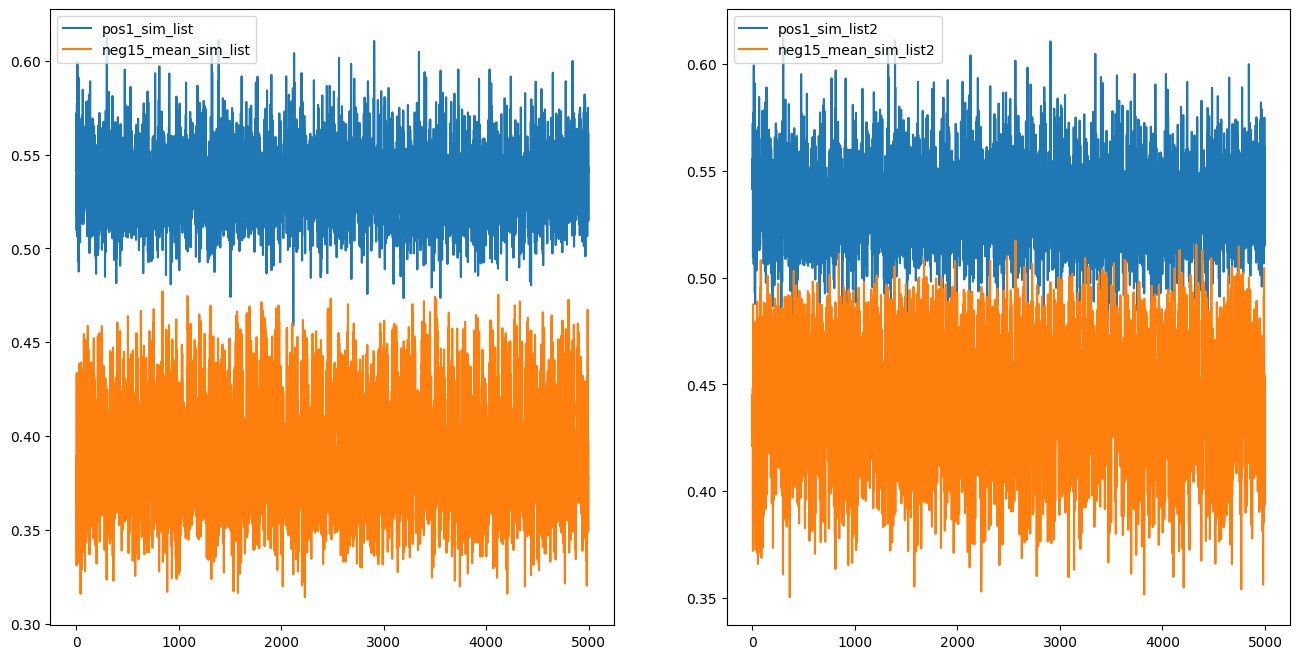

In [103]:
## 5000个样本画图对比 正/负样本的 cos_sim

import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(range(5000), pos1_sim_list)
plt.plot(range(5000), neg15_mean_sim_list)
plt.legend(['pos1_sim_list', 'neg15_mean_sim_list'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(range(5000), pos1_sim_list2)
plt.plot(range(5000), neg15_mean_sim_list2)
plt.legend(['pos1_sim_list2', 'neg15_mean_sim_list2'], loc='upper left')
plt.show()


#### score 差异图

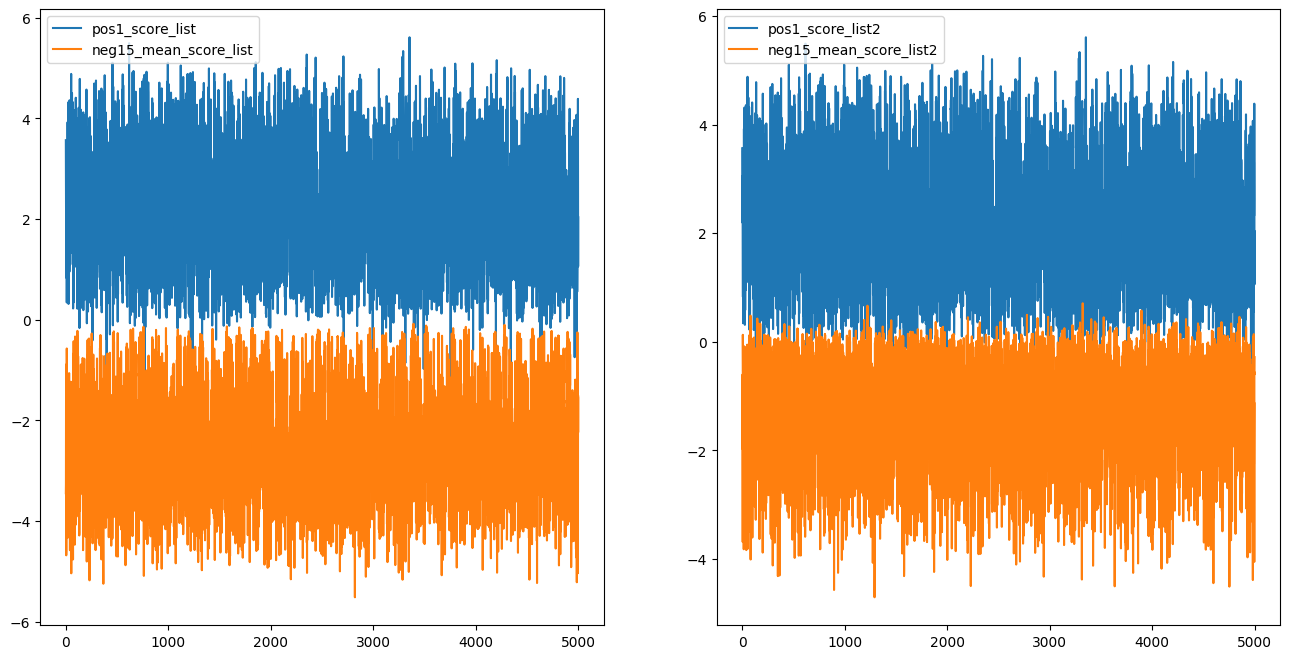

In [104]:
## 5000个样本画图对比 正/负样本的 score

import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(range(5000), pos1_score_list)
plt.plot(range(5000), neg15_mean_score_list)
plt.legend(['pos1_score_list', 'neg15_mean_score_list'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(range(5000), pos1_score_list2)
plt.plot(range(5000), neg15_mean_score_list2)
plt.legend(['pos1_score_list2', 'neg15_mean_score_list2'], loc='upper left')
plt.show()

In [105]:
## top32-128 和 top10-32 的pos_top1是相同的
np.sum([i-j for i,j in zip(pos1_score_list,pos1_score_list2)])

0.0

np.mean(diff_score_list),np.max(diff_score_list),np.min(diff_score_list) :  4.640823874067834 9.936019825935364 -0.6380796032647292
np.mean(diff_score_list2),np.max(diff_score_list2),np.min(diff_score_list2) :  3.373248888971424 9.144150733947754 -1.1184745381275814


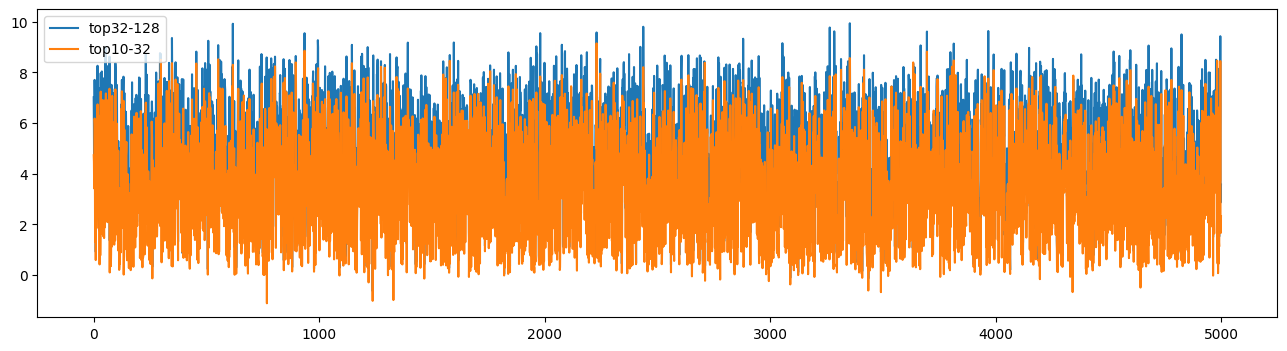

np.mean(diff_diff),np.max(diff_diff),np.min(diff_diff) :  1.267574985096411 4.843465114633243 -0.935751736164093


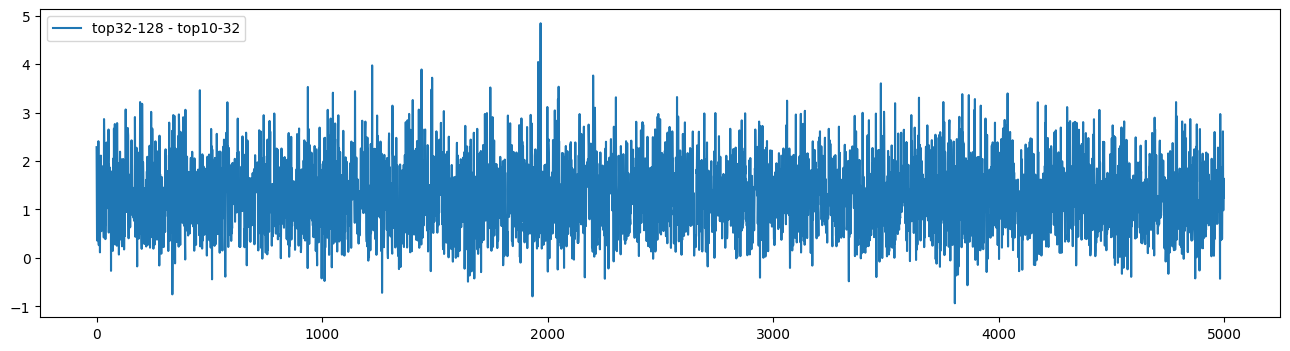

In [106]:
## 5000个样本画图对比 正/负样本的 score的差值
diff_score_list=[]
for pos1_score, neg15_mean_score in zip(pos1_score_list, neg15_mean_score_list):
    diff_score_list.append(pos1_score - neg15_mean_score)

diff_score_list2=[]
for pos1_score, neg15_mean_score in zip(pos1_score_list2, neg15_mean_score_list2):
    diff_score_list2.append(pos1_score - neg15_mean_score)

print("np.mean(diff_score_list),np.max(diff_score_list),np.min(diff_score_list) : ", np.mean(diff_score_list),np.max(diff_score_list),np.min(diff_score_list))
print("np.mean(diff_score_list2),np.max(diff_score_list2),np.min(diff_score_list2) : ",np.mean(diff_score_list2),np.max(diff_score_list2),np.min(diff_score_list2))

import matplotlib.pyplot as plt

plt.figure(figsize=(16,4))
# plt.subplot(1,2,1)
plt.plot(range(5000), diff_score_list)
plt.plot(range(5000), diff_score_list2)
plt.legend(['top32-128', 'top10-32'], loc='upper left')
plt.show()


diff_diff = [diff-diff2 for diff, diff2 in zip(diff_score_list, diff_score_list2)]
print("np.mean(diff_diff),np.max(diff_diff),np.min(diff_diff) : ",np.mean(diff_diff),np.max(diff_diff),np.min(diff_diff))
plt.figure(figsize=(16,4))
# plt.subplot(1,2,1)
plt.plot(range(5000), diff_diff)
plt.legend(['top32-128 - top10-32'], loc='upper left')
plt.show()

### top5-8 cos_sim/score 差异图


#### sampling

In [ ]:
## 极端负采样范围
neg_sample_range = [5, 8]

## 正样本取top1
top1_sims, top1_idxs = sims_matrix_i2t.topk(k=1, dim=1) #正样本直接使用top1 TODO 使用top5采样一个正样本？
top1_sims, top1_idxs =top1_sims[:,0], top1_idxs[:,0]
print("top1_idxs")
print(top1_idxs.shape)
print(top1_idxs[0])

## 负样本取top32-128采样15个
neg_sims, neg_idxs = sample_neg_idxs(sims_matrix_i2t, 4, 128, neg_sample_range=neg_sample_range)
print("neg_idxs")
print(neg_idxs.shape)
print(neg_idxs[0])
print()

## 拼接正负样本至同一个sample
sampled_sims_matrix_i2t_5_8 = []
sampled_sims_idx_i2t_5_8 = []
for i in range(sims_matrix_i2t.size(0)):
    sampled_sim = torch.concatenate((sims_matrix_i2t[i,top1_idxs[i]].reshape(-1), sims_matrix_i2t[i,neg_idxs[i]]))
    sampled_idx = torch.concatenate((top1_idxs[i].reshape(-1), neg_idxs[i]))
    sampled_sims_matrix_i2t_5_8.append(sampled_sim)
    sampled_sims_idx_i2t_5_8.append(sampled_idx)
sampled_sims_matrix_i2t_5_8 = torch.stack(sampled_sims_matrix_i2t_5_8) # shape=(5000, k_tta)
sampled_sims_idx_i2t_5_8 = torch.stack(sampled_sims_idx_i2t_5_8) # shape=(5000, k_tta)

## 采样后show sample
print("sampled_sims_matrix_i2t_5_8")
print(sampled_sims_matrix_i2t_5_8.shape)
print(sampled_sims_matrix_i2t_5_8[0])
print("sampled_sims_idx_i2t_5_8")
print(sampled_sims_idx_i2t_5_8.shape)
print(sampled_sims_idx_i2t_5_8[0])
print()

## 使用上述采样后的index，在score_dict中找到对应的score
sampled_score_i2t_5_8 = []
for score_dict, sampled_sims_idx in zip(score_i2t, sampled_sims_idx_i2t_5_8):
    # score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
    sampled_idx = []
    sampled_sim = []
    sampled_score = []
    # print(sampled_sims_idx)
    for idx, sim, score in zip(score_dict["topk_idx"], score_dict["topk_sim"], score_dict["score"]):
        if idx in sampled_sims_idx:
            # print(idx)
            # print(sim)
            # print(score)
            sampled_idx.append(idx)
            sampled_sim.append(sim)
            sampled_score.append(score)
    score_dict_sampled = {
        'recall_type': score_dict["recall_type"],
        'label': score_dict["label"],
        'topk_sim': sampled_sim,
        'topk_idx': sampled_idx,
        'score': sampled_score,
    }
    sampled_score_i2t_5_8.append(score_dict_sampled)

    # break

print(f"len(sampled_score_i2t_5_8) : {len(sampled_score_i2t_5_8)}")
print(f"sampled_score_i2t_5_8[0].keys() : {sampled_score_i2t_5_8[0].keys()}")
print(f"sampled_score_i2t_5_8[0]['recall_type'] : {sampled_score_i2t_5_8[0]['recall_type']}")
print(f"sampled_score_i2t_5_8[0]['topk_sim'] : {sampled_score_i2t_5_8[0]['topk_sim']}")
print(f"sampled_score_i2t_5_8[0]['topk_idx'] : {sampled_score_i2t_5_8[0]['topk_idx']}")
print(f"sampled_score_i2t_5_8[0]['score'] : {sampled_score_i2t_5_8[0]['score']}")
print()

top1_idxs
torch.Size([5000])
tensor(4)
neg_idxs
torch.Size([5000, 3])
tensor([23576, 13804, 13806])

sampled_sims_matrix_i2t_5_8
torch.Size([5000, 4])
tensor([0.5555, 0.4959, 0.5136, 0.5108])
sampled_sims_idx_i2t_5_8
torch.Size([5000, 4])
tensor([    4, 23576, 13804, 13806])

len(sampled_score_i2t_5_8) : 5000
sampled_score_i2t_5_8[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t_5_8[0]['recall_type'] : recall@1
sampled_score_i2t_5_8[0]['topk_sim'] : [0.5554964542388916, 0.5135940909385681, 0.5107924342155457, 0.4958907663822174]
sampled_score_i2t_5_8[0]['topk_idx'] : [4, 13804, 13806, 23576]
sampled_score_i2t_5_8[0]['score'] : [3.5666849613189697, 0.6491490602493286, 0.2784208357334137, -0.5024570226669312]



#### statistic analysis

In [124]:
## 对比top1正样本和3个负样本的score和cos_sim的差异
pos1_sim_list3 = []
neg3_sim_list3 = []

pos1_score_list3 = []
neg3_score_list3 = []

for dict in sampled_score_i2t_5_8:
    # print(dict["topk_sim"])
    pos1_sim_list3.append(dict["topk_sim"][0])
    neg3_sim_list3.append(dict["topk_sim"][1:])
    # print(pos1_sim_list)
    # print(neg3_sim_list3)
    pos1_score_list3.append(dict["score"][0])
    neg3_score_list3.append(dict["score"][1:])

# 前5个正样本 和 前5个负样本均值 对比
neg3_mean_sim_list3 = [np.mean(sim_list) for sim_list in neg3_sim_list3]
print(pos1_sim_list3[:5])
print(neg3_mean_sim_list3[:5])
print()
neg3_mean_score_list3 = [np.mean(score_list) for score_list in neg3_score_list3]
print(pos1_score_list3[:5])
print(neg3_mean_score_list3[:5])
neg3_max_score_list3 = [np.max(score_list) for score_list in neg3_score_list3]
print(pos1_score_list3[:5])
print(neg3_max_score_list3[:5])

# 所有正样本均值 和 所有负样本均值的均值 对比
print(np.mean(pos1_sim_list3), np.mean(neg3_mean_sim_list3))
print(np.mean(pos1_score_list3), np.mean(neg3_mean_score_list3), np.max(neg3_mean_score_list3), np.min(neg3_mean_score_list3))
print("正样本score均值 和 负样本score均值的均值 之差：",np.mean(pos1_score_list3) - np.mean(neg3_mean_score_list3))
print("正样本score 和 负样本score均值 之差 的均值：",np.mean([i-j for i,j in zip(pos1_score_list3, neg3_mean_score_list3) ]))
print("正样本score 和 负样本scorezu最大值 之差 的均值：",np.mean([i-j for i,j in zip(pos1_score_list3, neg3_max_score_list3) ]))

[0.5554964542388916, 0.5412729978561401, 0.561689019203186, 0.5721200704574585, 0.5331200361251831]
[0.5067590971787771, 0.4804241160551707, 0.47264060378074646, 0.49729358156522113, 0.47176573673884076]

[3.5666849613189697, 2.5098745822906494, 2.1974949836730957, 3.0514345169067383, 3.0197014808654785]
[0.14170429110527039, 0.5799348851044973, 0.03691797206799189, 0.944037914276123, 0.47213050723075867]
[3.5666849613189697, 2.5098745822906494, 2.1974949836730957, 3.0514345169067383, 3.0197014808654785]
[0.6491490602493286, 0.9604989886283875, 1.0100939273834229, 1.7928376197814941, 2.688812494277954]
0.534825471240282 0.48391853900750476
2.148819647923112 0.1517037603114266 3.481996456782023 -4.445097764333089
正样本score均值 和 负样本score均值的均值 之差： 1.9971158876116855
正样本score 和 负样本score均值 之差 的均值： 1.9971158876116852
正样本score 和 负样本scorezu最大值 之差 的均值： 1.2841302722318098


#### plt cos_sim

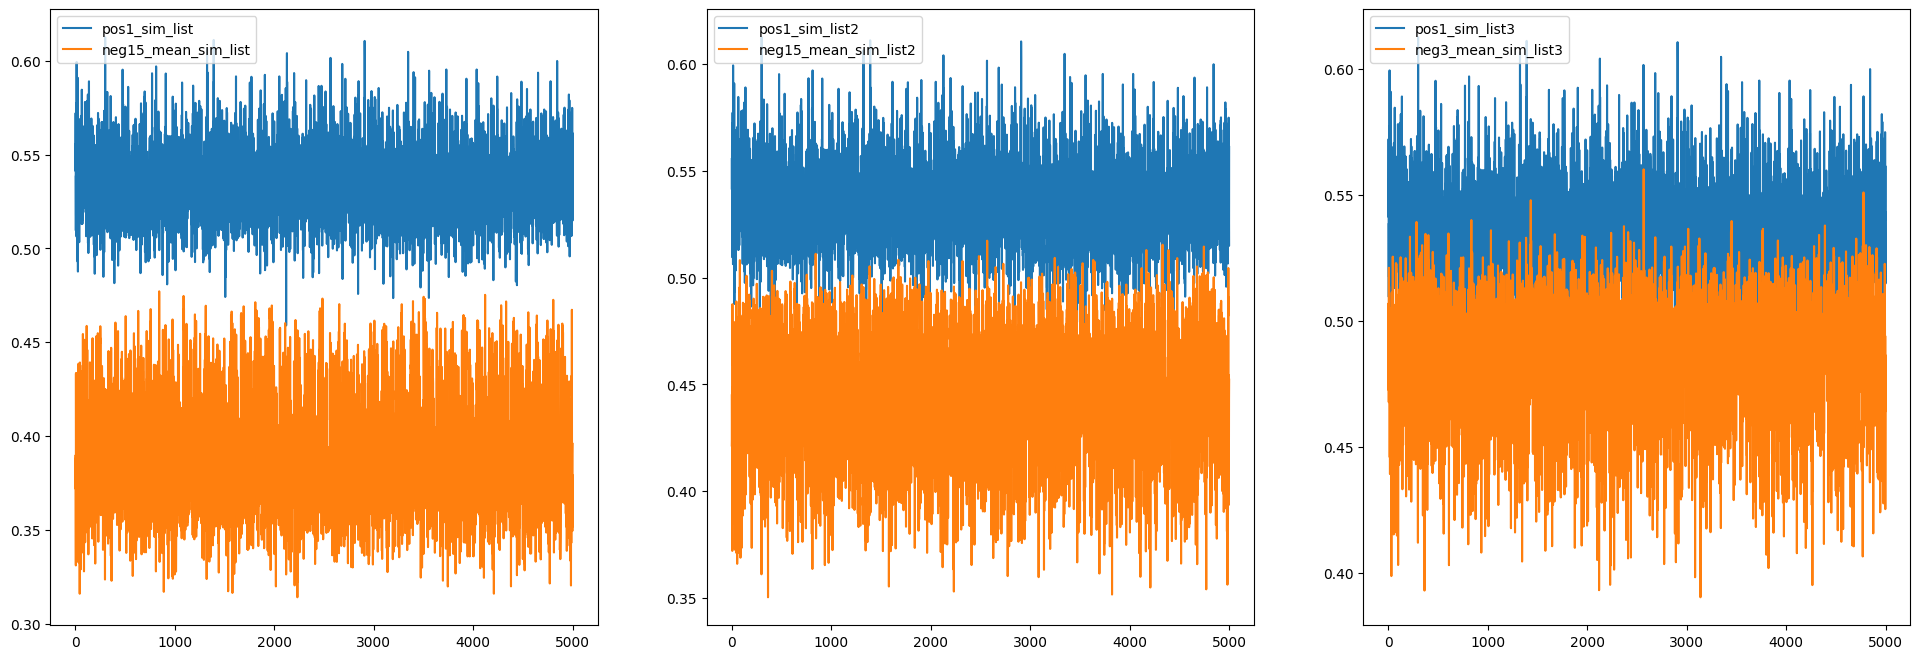

In [130]:
## 5000个样本画图对比 正/负样本的 cos_sim

import matplotlib.pyplot as plt

plt.figure(figsize=(24,8))
plt.subplot(1,3,1)
plt.plot(range(5000), pos1_sim_list)
plt.plot(range(5000), neg15_mean_sim_list)
plt.legend(['pos1_sim_list', 'neg15_mean_sim_list'], loc='upper left')
plt.subplot(1,3,2)
plt.plot(range(5000), pos1_sim_list2)
plt.plot(range(5000), neg15_mean_sim_list2)
plt.legend(['pos1_sim_list2', 'neg15_mean_sim_list2'], loc='upper left')
plt.subplot(1,3,3)
plt.plot(range(5000), pos1_sim_list3)
plt.plot(range(5000), neg3_mean_sim_list3)
plt.legend(['pos1_sim_list3', 'neg3_mean_sim_list3'], loc='upper left')
plt.show()


#### plt score

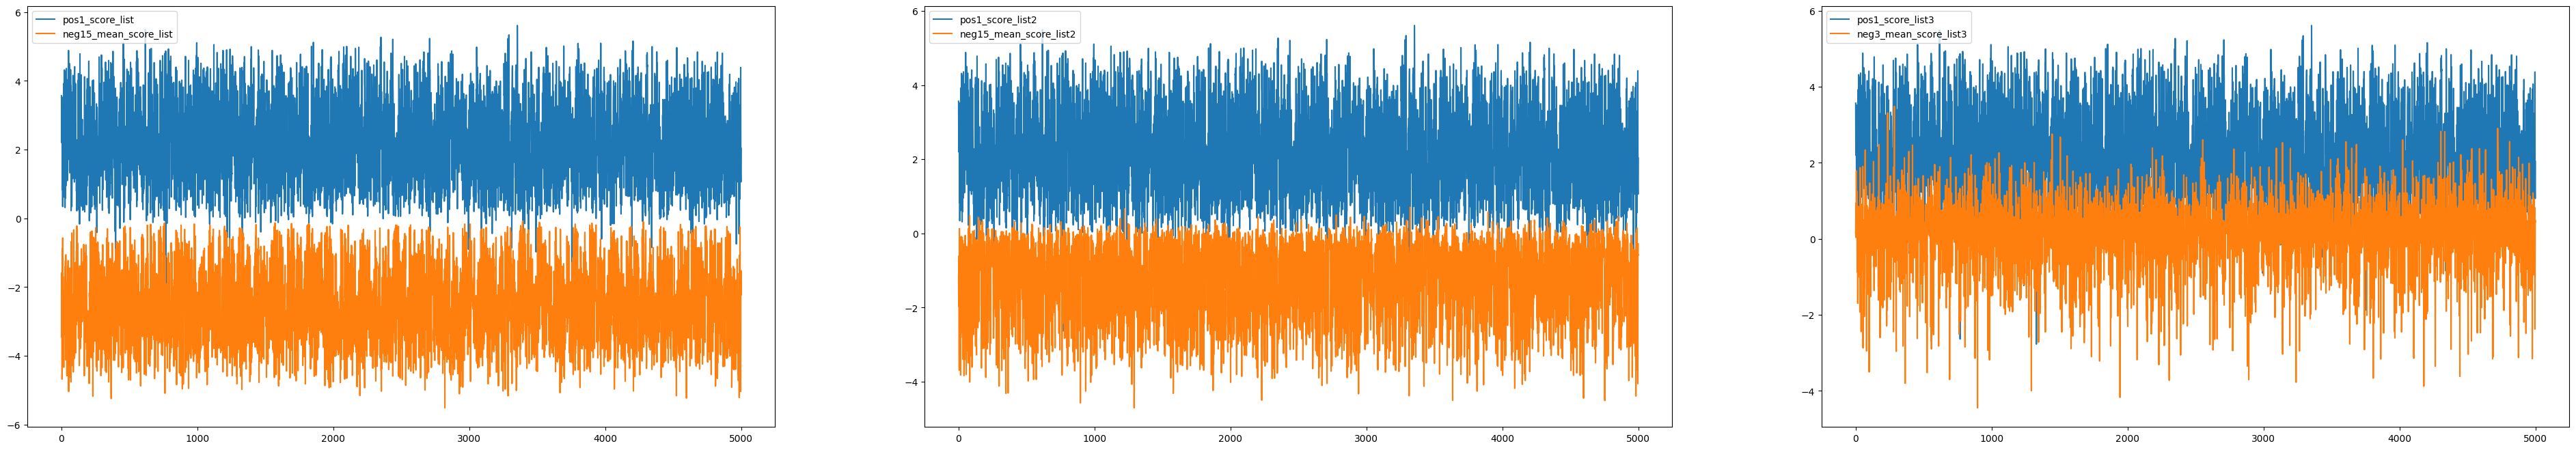

In [132]:
## 5000个样本画图对比 正/负样本的 score

import matplotlib.pyplot as plt

plt.figure(figsize=(48,8))
plt.subplot(1,3,1)
plt.plot(range(5000), pos1_score_list)
plt.plot(range(5000), neg15_mean_score_list)
plt.legend(['pos1_score_list', 'neg15_mean_score_list'], loc='upper left')
plt.subplot(1,3,2)
plt.plot(range(5000), pos1_score_list2)
plt.plot(range(5000), neg15_mean_score_list2)
plt.legend(['pos1_score_list2', 'neg15_mean_score_list2'], loc='upper left')
plt.subplot(1,3,3)
plt.plot(range(5000), pos1_score_list3)
plt.plot(range(5000), neg3_mean_score_list3)
plt.legend(['pos1_score_list3', 'neg3_mean_score_list3'], loc='upper left')
plt.show()


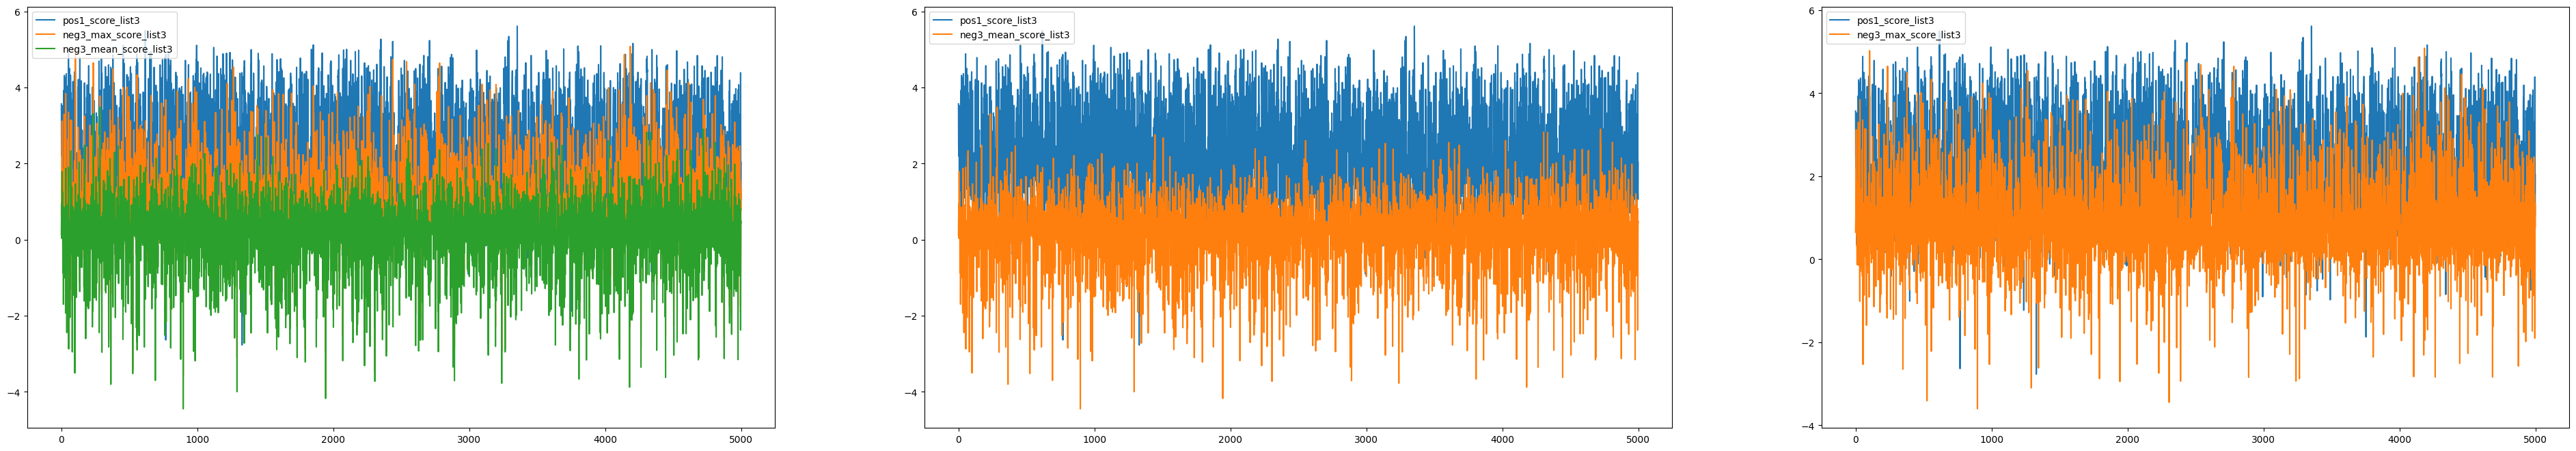

In [134]:
plt.figure(figsize=(48,8))
plt.subplot(1,3,1)
plt.plot(range(5000), pos1_score_list3)
plt.plot(range(5000), neg3_max_score_list3)
plt.plot(range(5000), neg3_mean_score_list3)
plt.legend(['pos1_score_list3', 'neg3_max_score_list3', 'neg3_mean_score_list3'], loc='upper left')
plt.subplot(1,3,2)
plt.plot(range(5000), pos1_score_list3)
plt.plot(range(5000), neg3_mean_score_list3)
plt.legend(['pos1_score_list3', 'neg3_mean_score_list3'], loc='upper left')
plt.subplot(1,3,3)
plt.plot(range(5000), pos1_score_list3)
plt.plot(range(5000), neg3_max_score_list3)
plt.legend(['pos1_score_list3', 'neg3_max_score_list3'], loc='upper left')
plt.show()

[2.148819647923112, -2.4920042261447226, 2.148819647923112, -1.2244292410483117, 2.148819647923112, 0.1517037603114266, 0.8646893756913021]


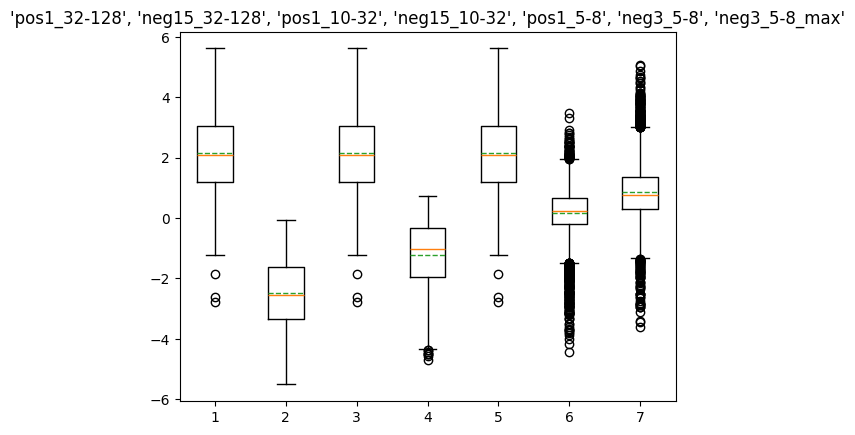

In [135]:
print([np.mean(i) for i in [pos1_score_list, neg15_mean_score_list, pos1_score_list2, neg15_mean_score_list2, pos1_score_list3, neg3_mean_score_list3, neg3_max_score_list3]])
plt.figure()
plt.boxplot([pos1_score_list, neg15_mean_score_list, pos1_score_list2, neg15_mean_score_list2, pos1_score_list3, neg3_mean_score_list3, neg3_max_score_list3], meanline=True, showmeans=True)
# plt.legend(['pos1_32-128', 'neg15_32-128', 'pos1_10-32', 'neg15_10-32', 'pos1_5-8', 'neg3_5-8'], loc="lower left")
plt.title("'pos1_32-128', 'neg15_32-128', 'pos1_10-32', 'neg15_10-32', 'pos1_5-8', 'neg3_5-8', 'neg3_5-8_max'")
plt.show()

i2t任务 负样本采样使用top5-8的score均值与正样本score有一定差距也有一定交叉
总体而言，正负样本差值有： top5-8 < top10-32 < top32-128

# exp() loss coeffi ~ recall_type

In [ ]:
import json
import numpy as np
import torch
import torch.nn.functional as F


one_epoch_coeffi_lists = []
# for epoch in range(9):
for rank in range(3):
    epoch = 0
    with open(f"/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.2.3/i2t/20250703210/result/rank{rank}/tta_epoch{epoch}_logging_list.json", "rt") as file:
        # print(type(file))
        coeffi_list_src = json.load(file)
        coeffi_list = json.loads(coeffi_list_src)

    # print(type(coeffi_list))
    print(len(coeffi_list))
    one_epoch_coeffi_lists.extend(coeffi_list)

print(len(one_epoch_coeffi_lists))
print(one_epoch_coeffi_lists[0].keys())
print(one_epoch_coeffi_lists[0]['recall_type'])
print(one_epoch_coeffi_lists[0]['tta_coeffi'])
print(len(one_epoch_coeffi_lists[0]['recall_type']))
print(len(one_epoch_coeffi_lists[0]['tta_coeffi']))
print(len(one_epoch_coeffi_lists[0]['entropy']))
print(len(one_epoch_coeffi_lists[0]['score']))

53
53
53
159
dict_keys(['sample_idx', 'label', 'score', 'recall_type', 'sims_i2t', 'idxs_i2t', 'tta_coeffi', 'entropy', 'loss'])
['recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@5', 'recall@1', 'recall@10', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@5', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@1', 'recall@5', 'recall@1', 'recall@1', 'recall@1', 'recall@5', 'recall@1']
[1.4979593753814697, 1.6744722127914429, 1.5583863258361816, 1.1688127517700195, 1.941449522972107, 2.026909828186035, 2.0808041095733643, 2.135435104370117, 1.1756569147109985, 2.0714871883392334, 1.5015764236450195, 1.5122532844543457, 2.0728354454040527, 1.234610676765442, 1.9189788103103638, 1.2919813394546509, 1.6074416637420654, 1.3944497108459473, 1.464218258857727, 1.6492431163787842, 1.6390414237976074, 1.6682517528533936, 1.3006618022918701, 2.0314457416534424, 1.2781687

In [65]:
tta_coeffi_list = []
recall_type_list = []
for coeffi_dict in one_epoch_coeffi_lists:
    tta_coeffi_list.extend(coeffi_dict['tta_coeffi'])
    recall_type_list.extend(coeffi_dict['recall_type'])

print(len(tta_coeffi_list))
print(len(recall_type_list))

5000
5000


In [75]:
import pandas as pd
pd.DataFrame(recall_type_list).value_counts()

0              
negative sample    3367
recall@1           1253
recall@5            332
recall@10            48
Name: count, dtype: int64

In [ ]:
recall_1_tta_coeffi_list = []
recall_5_tta_coeffi_list = []
recall_10_tta_coeffi_list = []
recall_neg_tta_coeffi_list = []
for recall_type, tta_coeffi in zip(recall_type_list, tta_coeffi_list):
    if recall_type == "recall@1":
        recall_1_tta_coeffi_list.append(tta_coeffi)
    elif recall_type == "recall@5":
        recall_5_tta_coeffi_list.append(tta_coeffi)
    elif recall_type == "recall@10":
        recall_10_tta_coeffi_list.append(tta_coeffi)
    elif recall_type == "negative sample":
        recall_neg_tta_coeffi_list.append(tta_coeffi)

print("np.mean(recall_1_tta_coeffi_list: ",np.mean(recall_1_tta_coeffi_list))
print("np.mean(recall_5_tta_coeffi_list: ",np.mean(recall_5_tta_coeffi_list))
print("np.mean(recall_10_tta_coeffi_list: ",np.mean(recall_10_tta_coeffi_list))
print("np.mean(recall_neg_tta_coeffi_list: ",np.mean(recall_neg_tta_coeffi_list))
print(len(recall_1_tta_coeffi_list))
print(len(recall_5_tta_coeffi_list))
print(len(recall_10_tta_coeffi_list))
print(len(recall_neg_tta_coeffi_list))

np.mean(recall_1_tta_coeffi_list:  1.6339253848396296
np.mean(recall_5_tta_coeffi_list:  1.8999622036893684
np.mean(recall_10_tta_coeffi_list:  2.000342500706514
np.mean(recall_neg_tta_coeffi_list:  1.7214829988284177
1253
332
48
3367


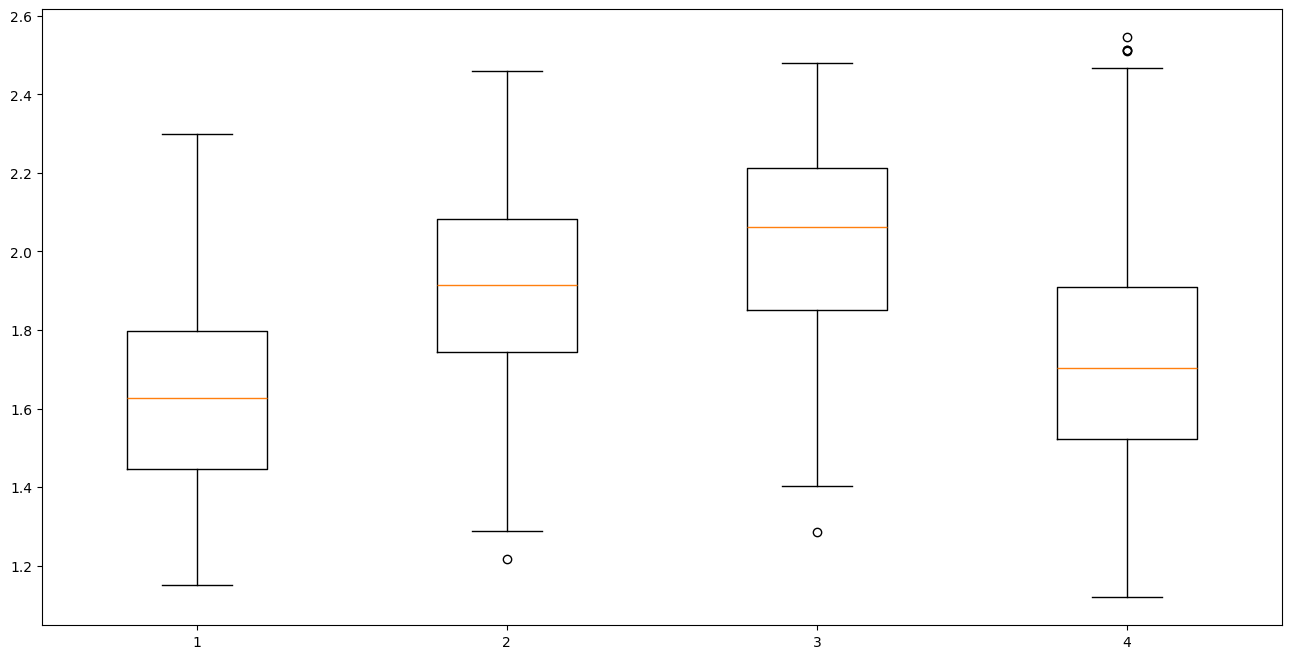

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.boxplot([recall_1_tta_coeffi_list,recall_5_tta_coeffi_list,recall_10_tta_coeffi_list,recall_neg_tta_coeffi_list])
plt.show()

# 修复训练代码中find_recall_types的bug

## exp() loss coeffi ~ recall_type

In [ ]:
def find_recall_type(label_list, topk_idx):
    label_list = label_list if isinstance(label_list, list) else [label_list]
    if topk_idx[0] in label_list:
        return "recall@1"
    else:
        for _idx in topk_idx[:5].tolist():
            if _idx in label_list:
                return "recall@5"
        for _idx in topk_idx[:10].tolist():
            if _idx in label_list:
                return "recall@10"
    return "negative sample"

def find_recall_types(labels, sims_matrix_i2t, k_test):
    recall_types = []
    for i, sims_i2t in enumerate(sims_matrix_i2t):
        label_list = labels[i]
        topk_sim, topk_idx = sims_i2t.topk(k=k_test, dim=0)
        recall_types.append(find_recall_type(label_list, topk_idx))
    return recall_types

In [ ]:
import numpy as np

def calculate_recall(topk_idx_sims, i2t_label):
    total_samples = len(i2t_label)
    recall_at_1 = 0
    recall_at_5 = 0
    recall_at_10 = 0
    recall_types = []

    for i in range(total_samples):
        true_label = i2t_label[i]
        topk_indices = topk_idx_sims[i]
        r1_flag = False
        r5_flag = False
        r10_flag = False

        for label in true_label:
            if label in topk_indices[:1].tolist():
                r1_flag = True
            if label in topk_indices[:5].tolist():
                r5_flag = True
            if label in topk_indices[:10].tolist():
                r10_flag = True

        if r1_flag:
            recall_at_1 += 1
        if r5_flag:
            recall_at_5 += 1
        if r10_flag:
            recall_at_10 += 1

        if r1_flag:
            recall_types.append("recall@1")
        elif r5_flag:
            recall_types.append("recall@5")
        elif r10_flag:
            recall_types.append("recall@10")
        elif r1_flag==False and r5_flag==False and r10_flag==False:
            recall_types.append("negative sample")

    recall_at_1 /= total_samples
    recall_at_5 /= total_samples
    recall_at_10 /= total_samples

    return (recall_at_1, recall_at_5, recall_at_10), recall_types

In [78]:
# Load the npy files
sims_i2t = np.load("debugs/debug_sim_matrix_i2t.npy")
sims_t2i = np.load("debugs/debug_sim_matrix_t2i.npy")
# score_i2t = np.load("debugs/score_matrix_i2t_debug.npy")
# score_t2i = np.load("debugs/score_matrix_t2i_debug.npy")

print("sims_i2t shape:", sims_i2t.shape)
print("sims_t2i shape:", sims_t2i.shape)
# print("score_i2t shape:", score_i2t.shape)
# print("score_t2i shape:", score_t2i.shape)

sims_i2t shape: (5000, 25010)
sims_t2i shape: (25010, 5000)


In [86]:
i2t_label = datasets["coco_retrieval"]["test"].img2txt # defined in title: model_origin

In [82]:
k = 128
## 按照sims without rerank排序
topk_idx_sims = np.argsort(-sims_i2t, axis=1)[:, :k]  # 按行取前 k 个索引
print("topk_idx_sims.shape:", topk_idx_sims.shape)

topk_idx_sims.shape: (5000, 128)


In [96]:
recall_scores, recall_types = calculate_recall(topk_idx_sims, i2t_label)
print(recall_scores)
print(len(recall_types))

(0.7434, 0.9424, 0.9742)
5000


In [94]:
find_recall_types(i2t_label, sims_i2t, k)

AttributeError: 'numpy.ndarray' object has no attribute 'topk'

In [ ]:
recall_1_tta_coeffi_list = []
recall_5_tta_coeffi_list = []
recall_10_tta_coeffi_list = []
recall_neg_tta_coeffi_list = []
for recall_type, tta_coeffi in zip(recall_types, tta_coeffi_list):
    if recall_type == "recall@1":
        recall_1_tta_coeffi_list.append(tta_coeffi)
    elif recall_type == "recall@5":
        recall_5_tta_coeffi_list.append(tta_coeffi)
    elif recall_type == "recall@10":
        recall_10_tta_coeffi_list.append(tta_coeffi)
    elif recall_type == "negative sample":
        recall_neg_tta_coeffi_list.append(tta_coeffi)

print("np.mean(recall_1_tta_coeffi_list: ",np.mean(recall_1_tta_coeffi_list))
print("np.mean(recall_5_tta_coeffi_list: ",np.mean(recall_5_tta_coeffi_list))
print("np.mean(recall_10_tta_coeffi_list: ",np.mean(recall_10_tta_coeffi_list))
print("np.mean(recall_neg_tta_coeffi_list: ",np.mean(recall_neg_tta_coeffi_list))
print(len(recall_1_tta_coeffi_list))
print(len(recall_5_tta_coeffi_list))
print(len(recall_10_tta_coeffi_list))
print(len(recall_neg_tta_coeffi_list))

np.mean(recall_1_tta_coeffi_list:  1.641046104426021
np.mean(recall_5_tta_coeffi_list:  1.8963490810825596
np.mean(recall_10_tta_coeffi_list:  1.9963145091098808
np.mean(recall_neg_tta_coeffi_list:  2.0643096367518106
3717
995
159
129


In [98]:
3717/5000

0.7434

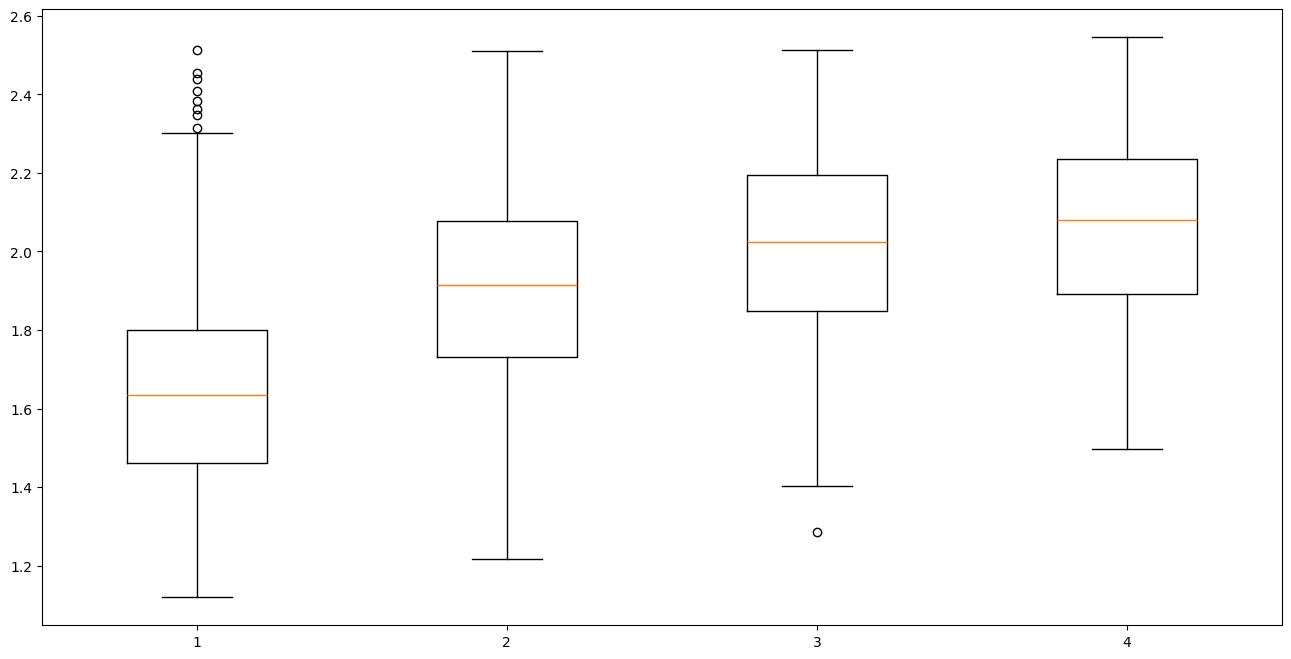

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.boxplot([recall_1_tta_coeffi_list,recall_5_tta_coeffi_list,recall_10_tta_coeffi_list,recall_neg_tta_coeffi_list])
plt.show()